# Exploratory Data Analysis Summary

This document summarizes the key findings from the exploratory data analysis (EDA) conducted on the well log dataset. The goals are to identify the well distribution, the most relevant logs for geological and geophysical analysis, and to understand their distributions and characteristics.

## Data Cleaning

We first cleaned the dataset by removing invalid or outlier values based on known physical limits for each log type, they originate from service-company chart conventions and API-RP standards used in well-log presentation. There isn’t a single unified “official” API table, but the standard values are consistent across the main service-company manuals. The table below summarizes the cleaning criteria applied to each log type.

| name | name extended | scale | unit |
|------|----------------|-------|------|
| GR   | Gamma Ray      | 0 - 150 | API  |
| SP   | Spontaneous Potential | -100 to +100 | mV   |
| DT   | Sonic (Compressional slowness) | 40 - 140 | µs/ft |
| CALI | Caliper        | 6 - 16 | inches |
| ILD  | Deep Induction Resistivity | 0.2 - 2000 (logarithmic scale) | ohm·m |
| RHOB | Bulk Density | 1.95 - 2.95 | g/cm³ |
| NPHI | Neutron Porosity | 0 - 0.45 (sometimes plotted reverse, 45-0) | fraction (v/v) |
| MSFL | Micro Spherically Focused Log | 0.2 - 2000 (logarithmic scale) | ohm·m |
| DRHO | Density Correction | -0.1 - +0.3 | g/cm³ |
| SFLU | Shallow Laterolog (Unfocused) | 0.2 - 2000 (logarithmic scale) | ohm·m |

These logs were selected based on how frequently they are present in the dataset and their relevance to common geological interpretations.

The formula below shows how to calculate the paretto chart used for selecting the most frequent log types:

1. Sort the data in descending order.
2. Calculate the cumulative sum of the values.
3. Calculate the cumulative percentage of the total.
4. Plot the sorted values as bars and the cumulative percentage as a line.

$$y_i = \frac{x_i}{\sum_{j=1}^{n} x_j} \times 100$$

In [241]:
from slide.models.featurePolicy import DefaultFeatures
import pandas as pd
import sqlite3
import numpy as np
import seaborn as sns
from scipy import stats



#policy = DefaultFeatures(appl, apply_presence=False, apply_rolling_stats=False)
conn = sqlite3.connect('../slide/database/features.db')
sql = """
SELECT  
	Features.basin,
	Features.well,
	Features.depth,
	CASE WHEN Features.GR BETWEEN 0 AND 150 THEN Features.GR ELSE NULL END AS GR,
	CASE WHEN Features.SP BETWEEN -100 AND 100 THEN Features.SP ELSE NULL END AS SP,
	CASE WHEN Features.DT BETWEEN 40 AND 140 THEN Features.DT ELSE NULL END AS DT,
	CASE WHEN Features.CALI BETWEEN 6 AND 16 THEN Features.CALI ELSE NULL END AS CALI,
	CASE WHEN Features.ILD BETWEEN 0.2 AND 2000 THEN Features.ILD ELSE NULL END AS ILD,
	CASE WHEN Features.RHOB BETWEEN 1.95 AND 2.95 THEN Features.RHOB ELSE NULL END AS RHOB,
	CASE WHEN Features.NPHI BETWEEN -15 AND 45 THEN Features.NPHI ELSE NULL END AS NPHI,
	CASE WHEN Features.MSFL BETWEEN 0.2 AND 2000 THEN Features.MSFL ELSE NULL END AS MSFL,
	CASE WHEN Features.DRHO BETWEEN -0.25 AND 0.25 THEN Features.DRHO ELSE NULL END AS DRHO,
	CASE WHEN Features.SFLU BETWEEN 0.2 AND 2000 THEN Features.SFLU ELSE NULL END AS SFLU,
	Features.rock AS lithology
FROM Features
WHERE
	Features.rock IN ('FOLHELHO', 'ARENITO', 'SILTITO', 'CALCILUTITO', 'AREIA', 'CALCARENITO',
'ARGILA', 'CALCARIO', 'CONGLOMERADO', 'ARGILITO', 'ANIDRITA', 'MARGA', 'GRANITO', 'BASALTO', 'DOLOMITO')
"""
print(sql)
df_features = pd.read_sql_query(sql, conn)
df_features.info()


SELECT  
	Features.basin,
	Features.well,
	Features.depth,
	CASE WHEN Features.GR BETWEEN 0 AND 150 THEN Features.GR ELSE NULL END AS GR,
	CASE WHEN Features.SP BETWEEN -100 AND 100 THEN Features.SP ELSE NULL END AS SP,
	CASE WHEN Features.DT BETWEEN 40 AND 140 THEN Features.DT ELSE NULL END AS DT,
	CASE WHEN Features.CALI BETWEEN 6 AND 16 THEN Features.CALI ELSE NULL END AS CALI,
	CASE WHEN Features.ILD BETWEEN 0.2 AND 2000 THEN Features.ILD ELSE NULL END AS ILD,
	CASE WHEN Features.RHOB BETWEEN 1.95 AND 2.95 THEN Features.RHOB ELSE NULL END AS RHOB,
	CASE WHEN Features.NPHI BETWEEN -15 AND 45 THEN Features.NPHI ELSE NULL END AS NPHI,
	CASE WHEN Features.MSFL BETWEEN 0.2 AND 2000 THEN Features.MSFL ELSE NULL END AS MSFL,
	CASE WHEN Features.DRHO BETWEEN -0.25 AND 0.25 THEN Features.DRHO ELSE NULL END AS DRHO,
	CASE WHEN Features.SFLU BETWEEN 0.2 AND 2000 THEN Features.SFLU ELSE NULL END AS SFLU,
	Features.rock AS lithology
FROM Features
WHERE
	Features.rock IN ('FOLHELHO', 'ARENITO',

In [242]:
target_column = 'lithology'
features_columns = [
        'depth',
        'GR', 
        'SP', 
        'DT', 
        'CALI', 
        'ILD', 
        'RHOB', 
        'NPHI', 
        'MSFL',
        'DRHO', 
        'SFLU']
valid_rocks = [
    'FOLHELHO', 'ARENITO', 'SILTITO', 'CALCILUTITO', 'AREIA', 'CALCARENITO',
    'ARGILA', 'CALCARIO', 'CONGLOMERADO', 'ARGILITO', 'ANIDRITA', 'MARGA',
    'GRANITO', 'BASALTO', 'DOLOMITO'
]
numeric_columns = df_features.select_dtypes(include=[np.number]).columns
df_features_filtered = df_features

In [231]:
is_log_transformed = False

In [232]:
########################## FEATURE VALUES BY ROCK TYPE ANALYSIS ##########################
"""
This analysis shows which feature values best represent each rock type.
We'll use several visualization techniques:
1. Box plots - show distribution and median for each feature by rock
2. Violin plots - show full distribution shape by rock
3. Summary statistics table - mean, median, std for each feature-rock combination
4. Radar/spider plots - compare feature profiles across rocks
5. Heatmap - correlations between features and rock types
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define features to analyze (excluding 'top' as you mentioned)
analysis_features = ["depth", "GR", "SP", "DT", "CALI", "ILD", "RHOB", "NPHI", "MSFL", "DRHO", "SFLU"]

# Create a clean dataset for analysis
#df_analysis = df_features[analysis_features + ['rock']].dropna(subset=['rock'])

# ============ 1. SUMMARY STATISTICS TABLE ============
print("\n" + "="*100)
print("FEATURE VALUES BY ROCK TYPE - SUMMARY STATISTICS")
print("="*100)

if not is_log_transformed:
    print("Applying log10 transformation to ILD, MSFL, and SFLU for better interpretability...")
    df_features_filtered['ILD'] = np.log10(df_features_filtered['ILD'])
    df_features_filtered['MSFL'] = np.log10(df_features_filtered['MSFL'])
    df_features_filtered['SFLU'] = np.log10(df_features_filtered['SFLU'])
    is_log_transformed = True

summary_stats = df_features_filtered.groupby(target_column)[analysis_features].agg(['mean', 'median', 'std', 'min', 'max']).round(2)
print(summary_stats)

# Create a simplified mean values table for easier interpretation
mean_by_rock = df_features_filtered.groupby(target_column)[analysis_features].mean().round(2)
print("\nMEAN VALUES BY ROCK TYPE:")
print(mean_by_rock)



FEATURE VALUES BY ROCK TYPE - SUMMARY STATISTICS
Applying log10 transformation to ILD, MSFL, and SFLU for better interpretability...
                depth                                       GR                \
                 mean   median      std    min      max   mean median    std   
lithology                                                                      
ANIDRITA      1193.97  1027.00   657.53   9.07  4202.00  32.56  23.76  27.64   
AREIA          609.12   383.00   635.12   4.10  2795.00  28.49  21.45  31.09   
ARENITO       1187.65   942.00   903.47   3.20  5911.00  64.78  65.25  29.23   
ARGILA         482.28   346.20   484.89   3.20  3089.00  30.44  16.10  33.75   
ARGILITO       601.11   489.40   450.73   4.11  3728.00  91.86  97.25  34.63   
BASALTO        541.63   490.20   365.82   4.00  3744.60  42.05  36.77  21.81   
CALCARENITO    427.98   277.60   490.77   3.20  4708.50  37.50  31.14  21.58   
CALCARIO      1414.66  1364.20   749.50  40.20  4510.00  52.49  58

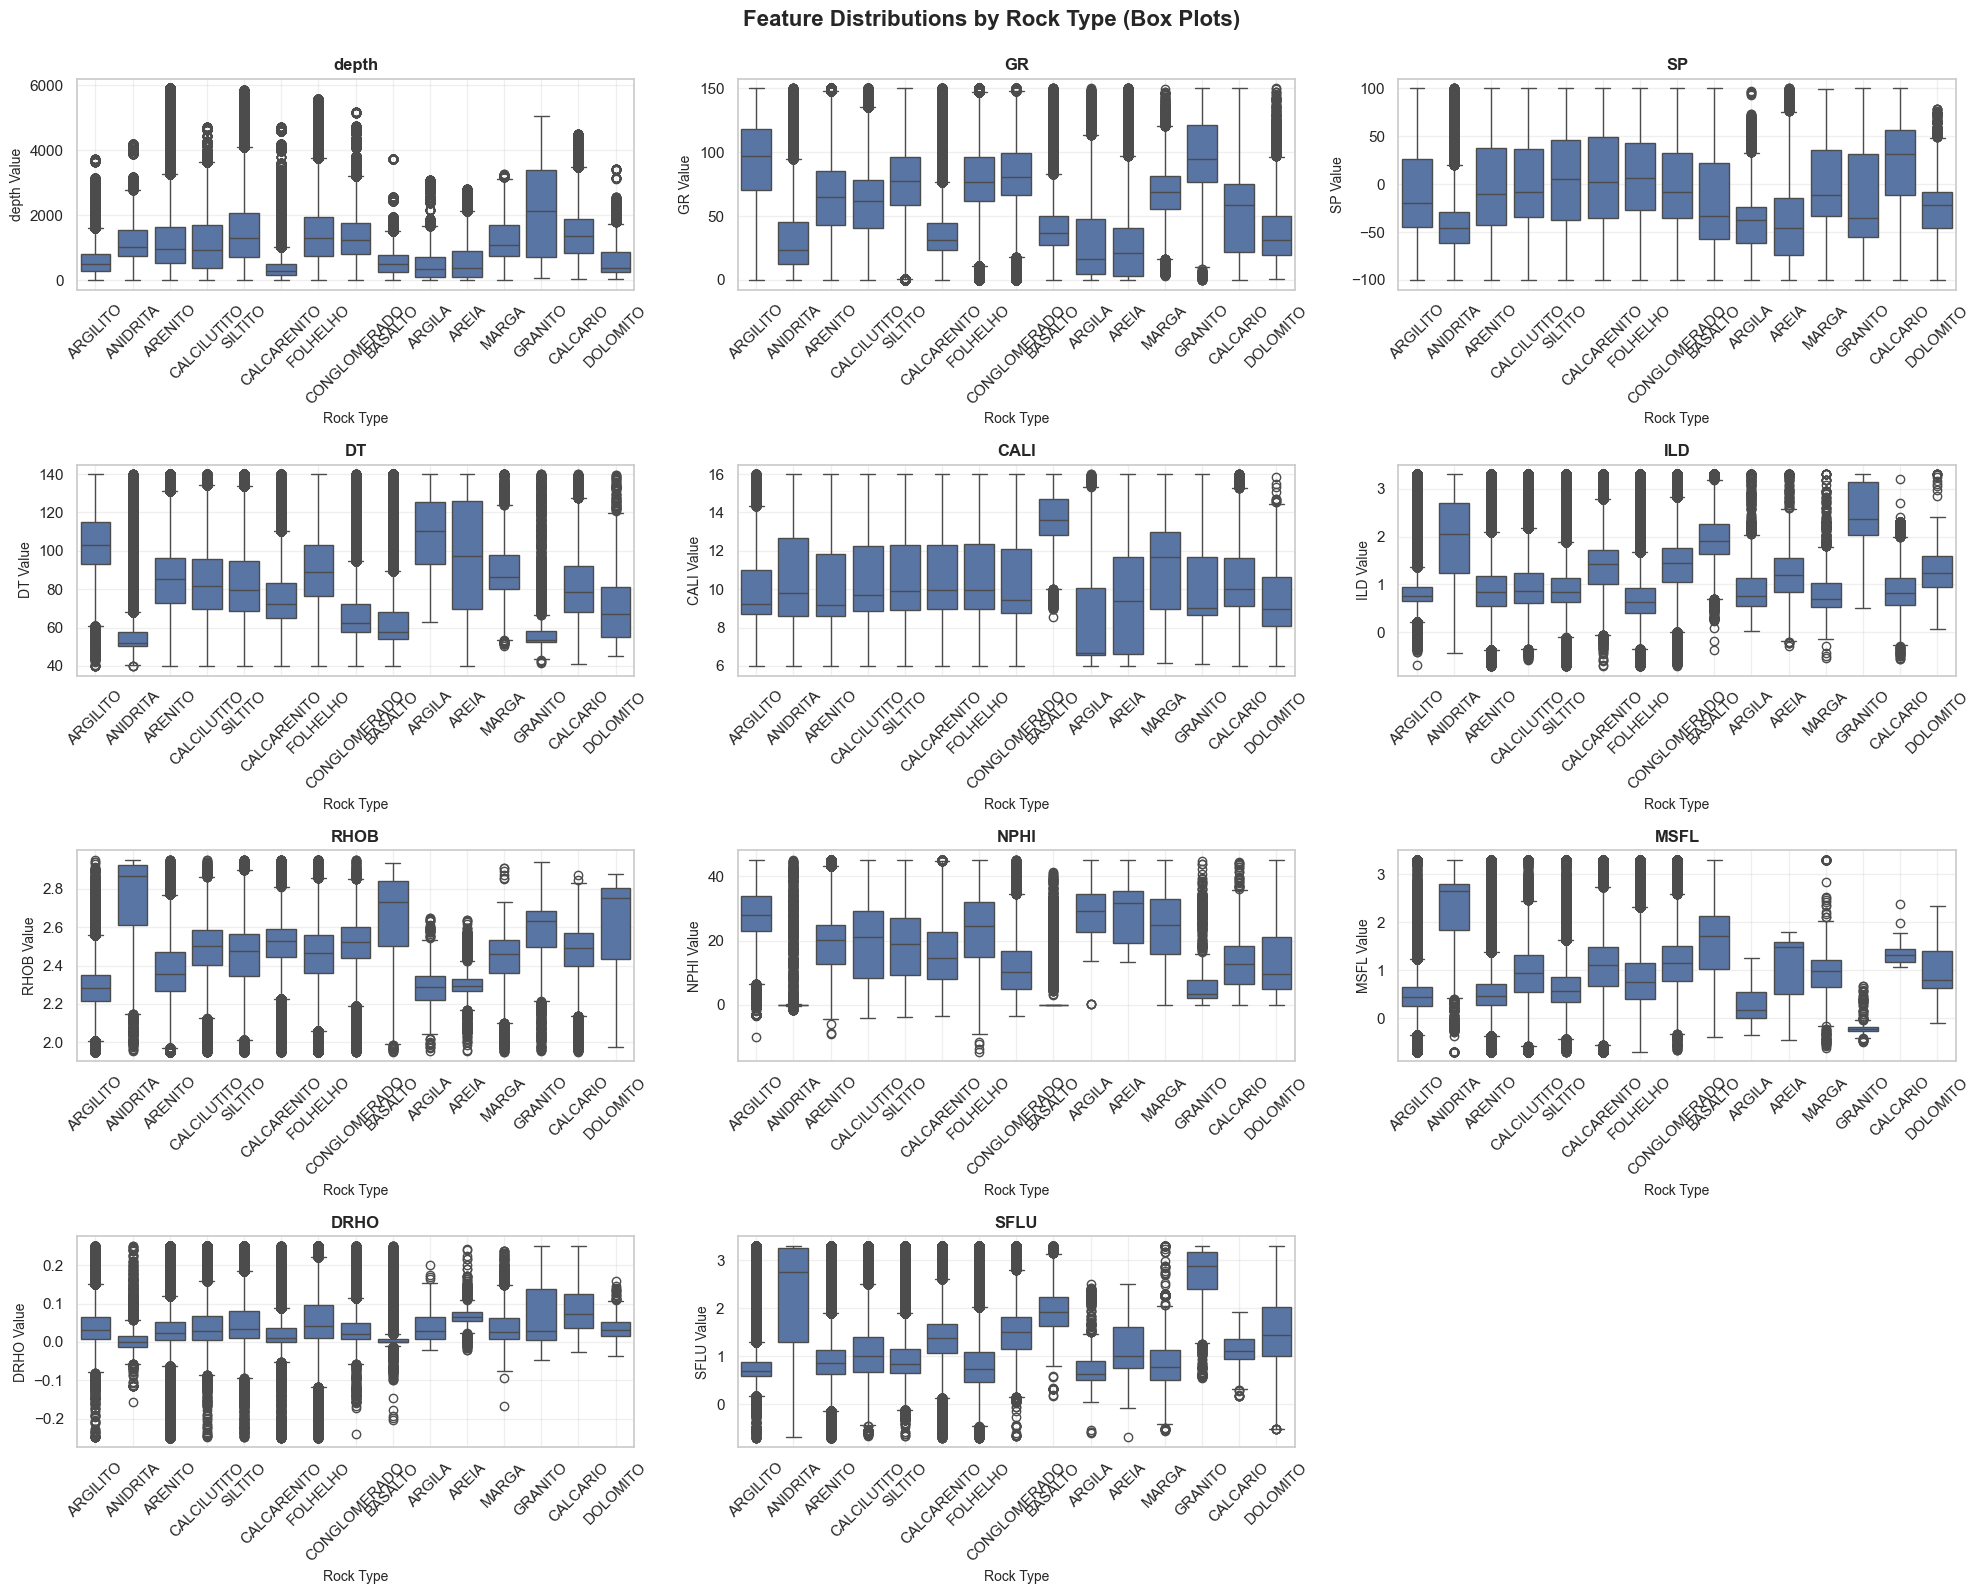

In [89]:
import seaborn as sns
sns.set_theme(context='notebook', style='whitegrid', palette='deep', font='sans-serif', font_scale=1, color_codes=True, rc=None)

# ============ 2. BOX PLOTS - Distribution by Rock ============
fig, axes = plt.subplots(4, 3, figsize=(20, 16))
fig.suptitle('Feature Distributions by Rock Type (Box Plots)', fontsize=16, fontweight='bold', y=0.995)

for idx, feature in enumerate(analysis_features):
    ax = axes[idx // 3, idx % 3]
    
    # Create box plot
    sns.boxplot(data=df_features_filtered, x=target_column, y=feature, ax=ax)
    ax.set_title(f'{feature}', fontsize=12, fontweight='bold')
    #ax.set_xlabel('Rock Type', fontsize=10)
    ax.set_ylabel(f'{feature} Value', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

# Hide the extra subplot
axes[3, 2].set_visible(False)

plt.tight_layout()
plt.show()



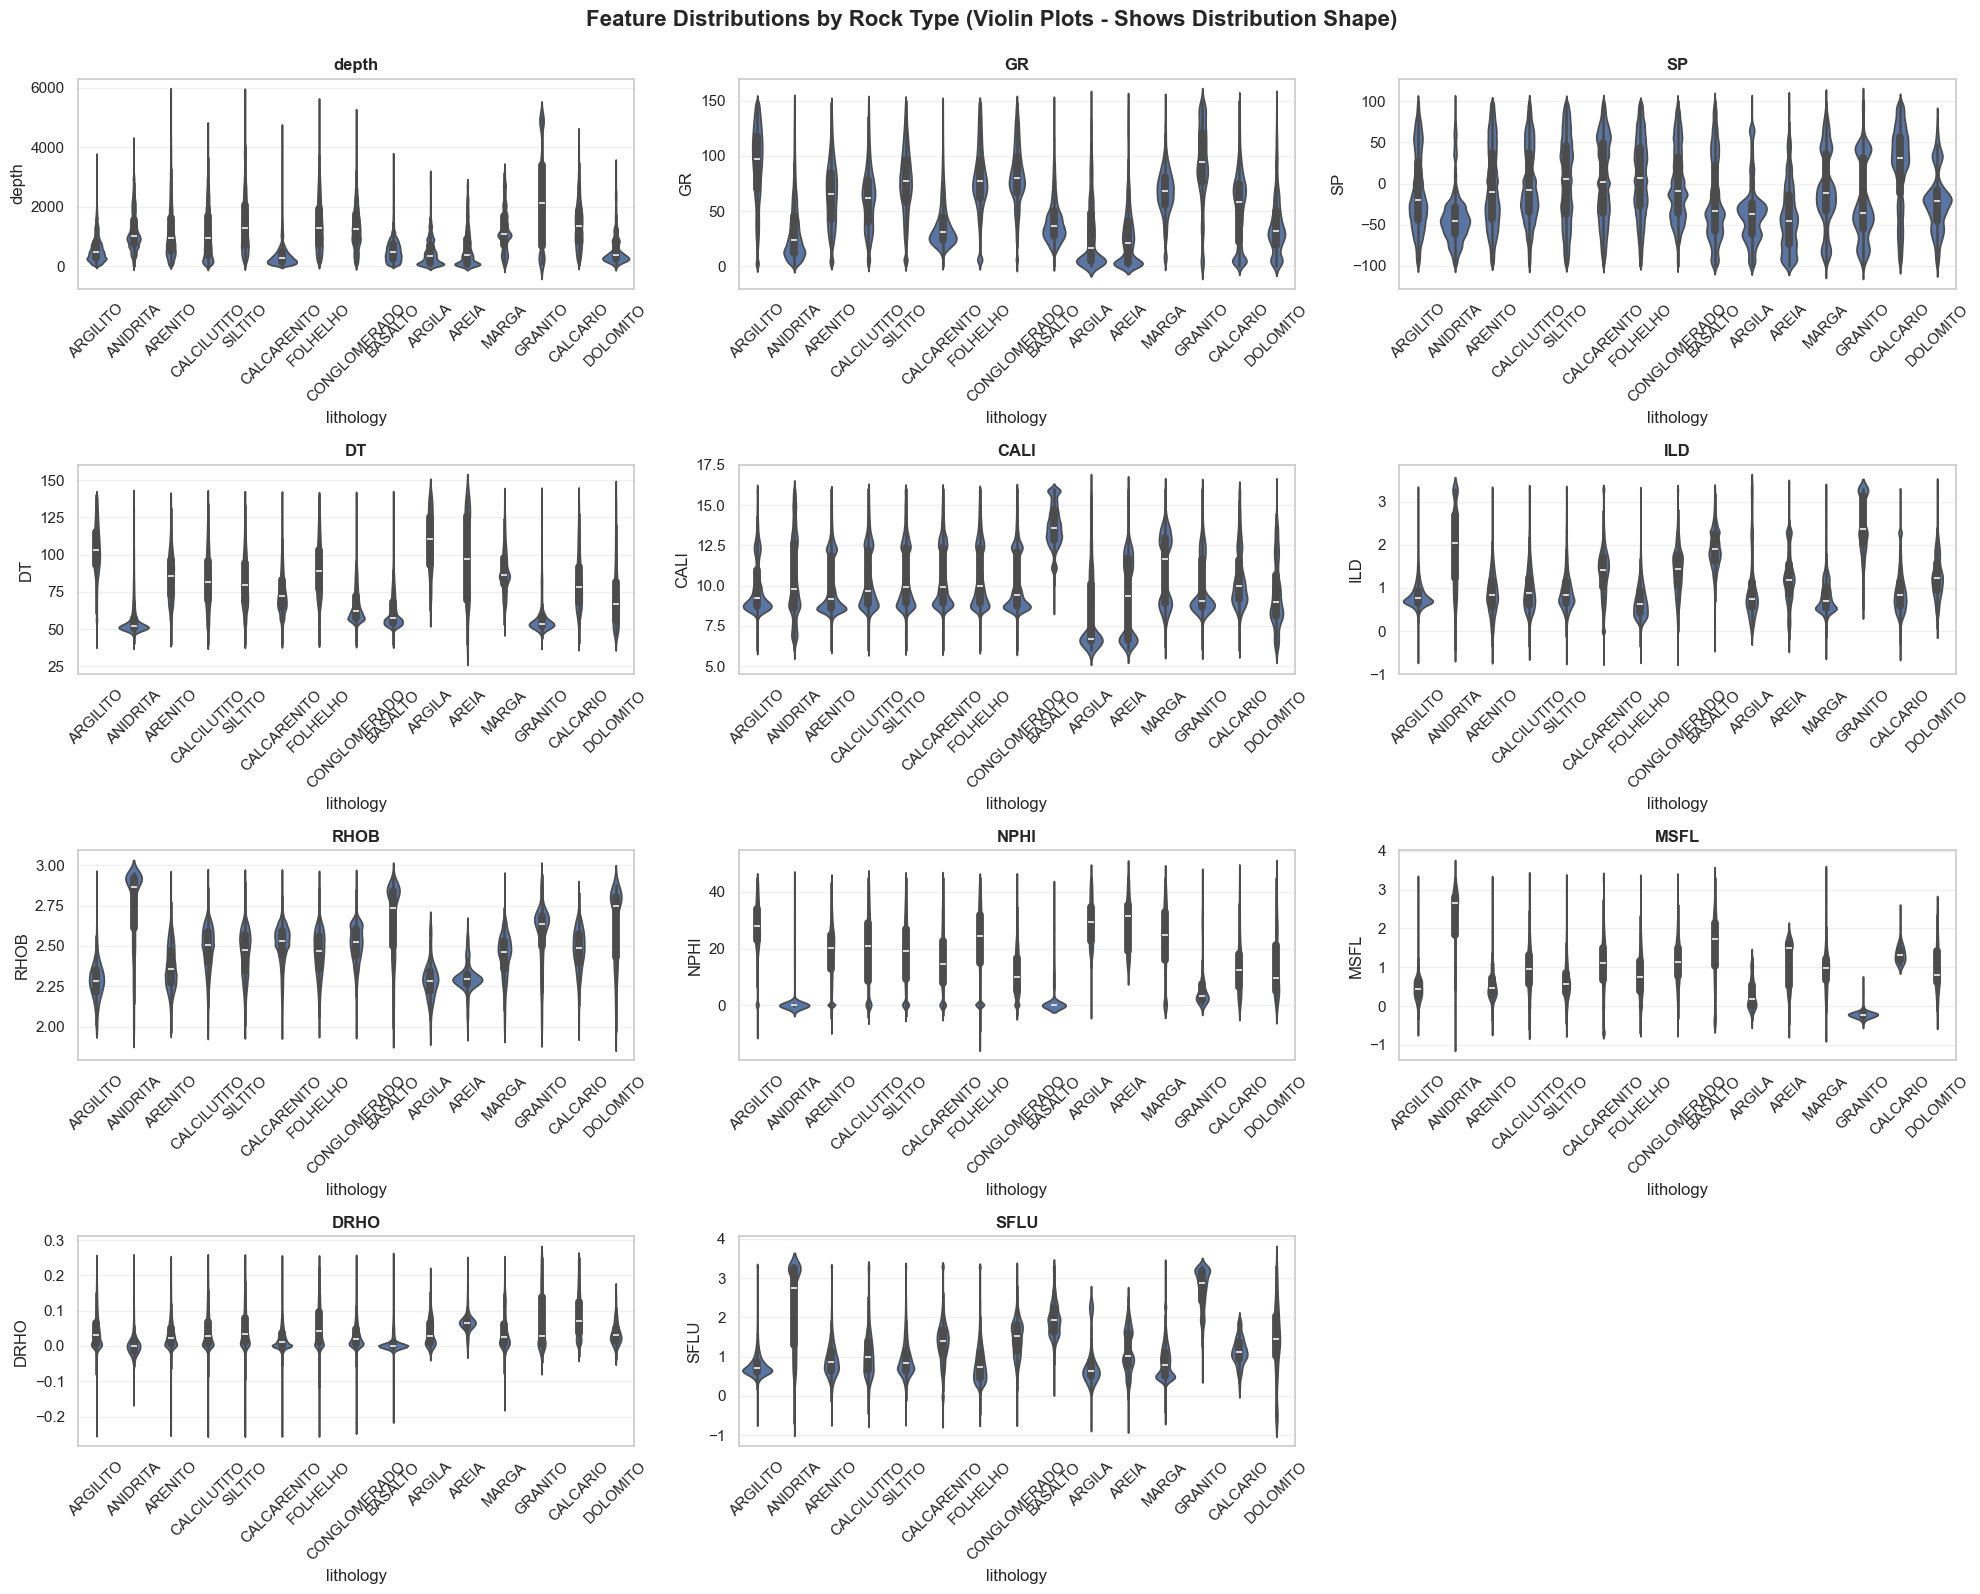

In [ ]:
# ============ 3. VIOLIN PLOTS - Full Distribution Shape ============
fig, axes = plt.subplots(4, 3, figsize=(20, 16))
fig.suptitle('Feature Distributions by Rock Type (Violin Plots - Shows Distribution Shape)', 
             fontsize=16, fontweight='bold', y=0.995)

for idx, feature in enumerate(analysis_features):
    ax = axes[idx // 3, idx % 3]
    
    # Create violin plot
    sns.violinplot(data=df_features_filtered, x=target_column, y=feature, ax=ax, inner='quartile')
    ax.set_title(f'{feature}', fontsize=12, fontweight='bold')
    #ax.set_xlabel('Rock Type', fontsize=10)
    #ax.set_ylabel(f'{feature} Value', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')

axes[3, 2].set_visible(False)

plt.tight_layout()
plt.show()

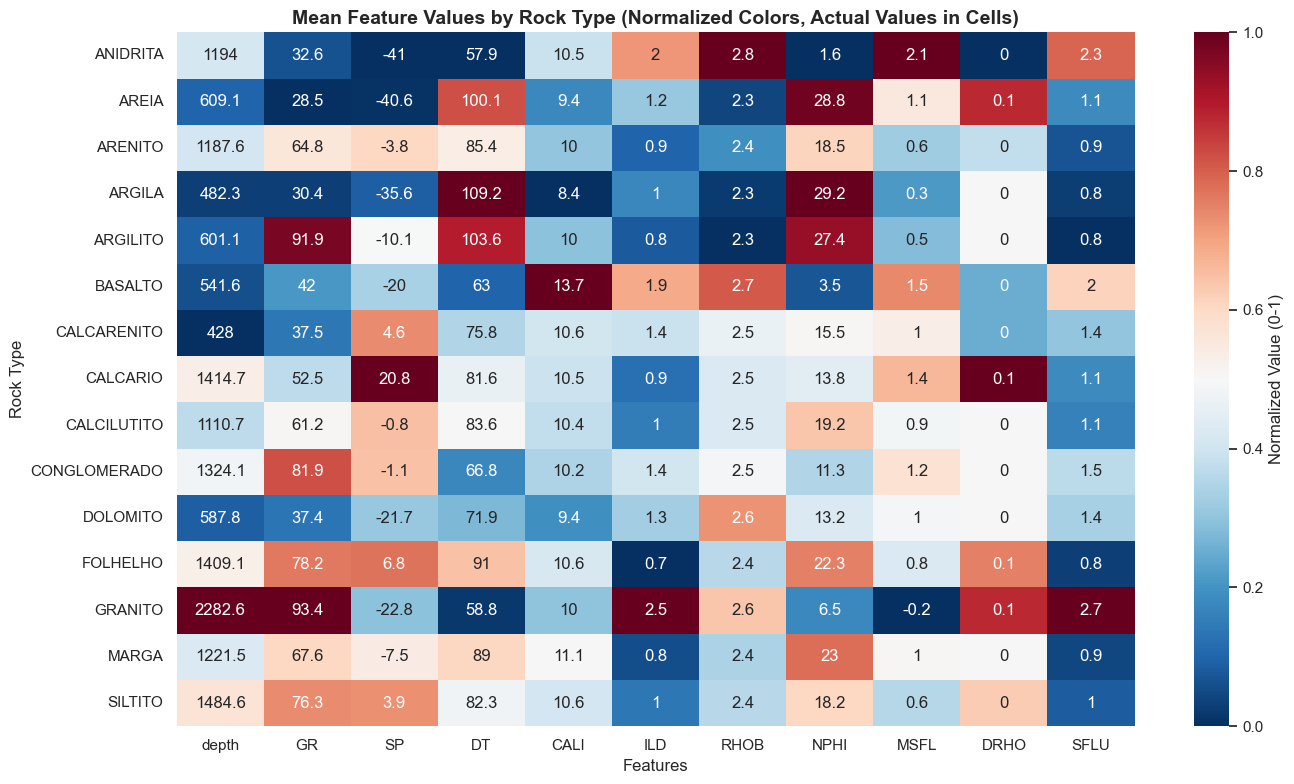

In [91]:
# ============ 4. HEATMAP - Mean Values by Rock Type ============
fig, ax = plt.subplots(figsize=(14, 8))

# Normalize features for better visualization (0-1 scale per feature)
mean_by_rock_normalized = mean_by_rock.copy()
for col in analysis_features:
    col_min = mean_by_rock[col].min()
    col_max = mean_by_rock[col].max()
    if col_max > col_min:
        mean_by_rock_normalized[col] = (mean_by_rock[col] - col_min) / (col_max - col_min)
    else:
        mean_by_rock_normalized[col] = 0.5

sns.heatmap(mean_by_rock_normalized, annot=mean_by_rock.round(1), fmt='g', 
            cmap='RdBu_r', ax=ax, cbar_kws={'label': 'Normalized Value (0-1)'})
ax.set_title('Mean Feature Values by Rock Type (Normalized Colors, Actual Values in Cells)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Features', fontsize=12)
ax.set_ylabel('Rock Type', fontsize=12)
plt.tight_layout()
plt.show()



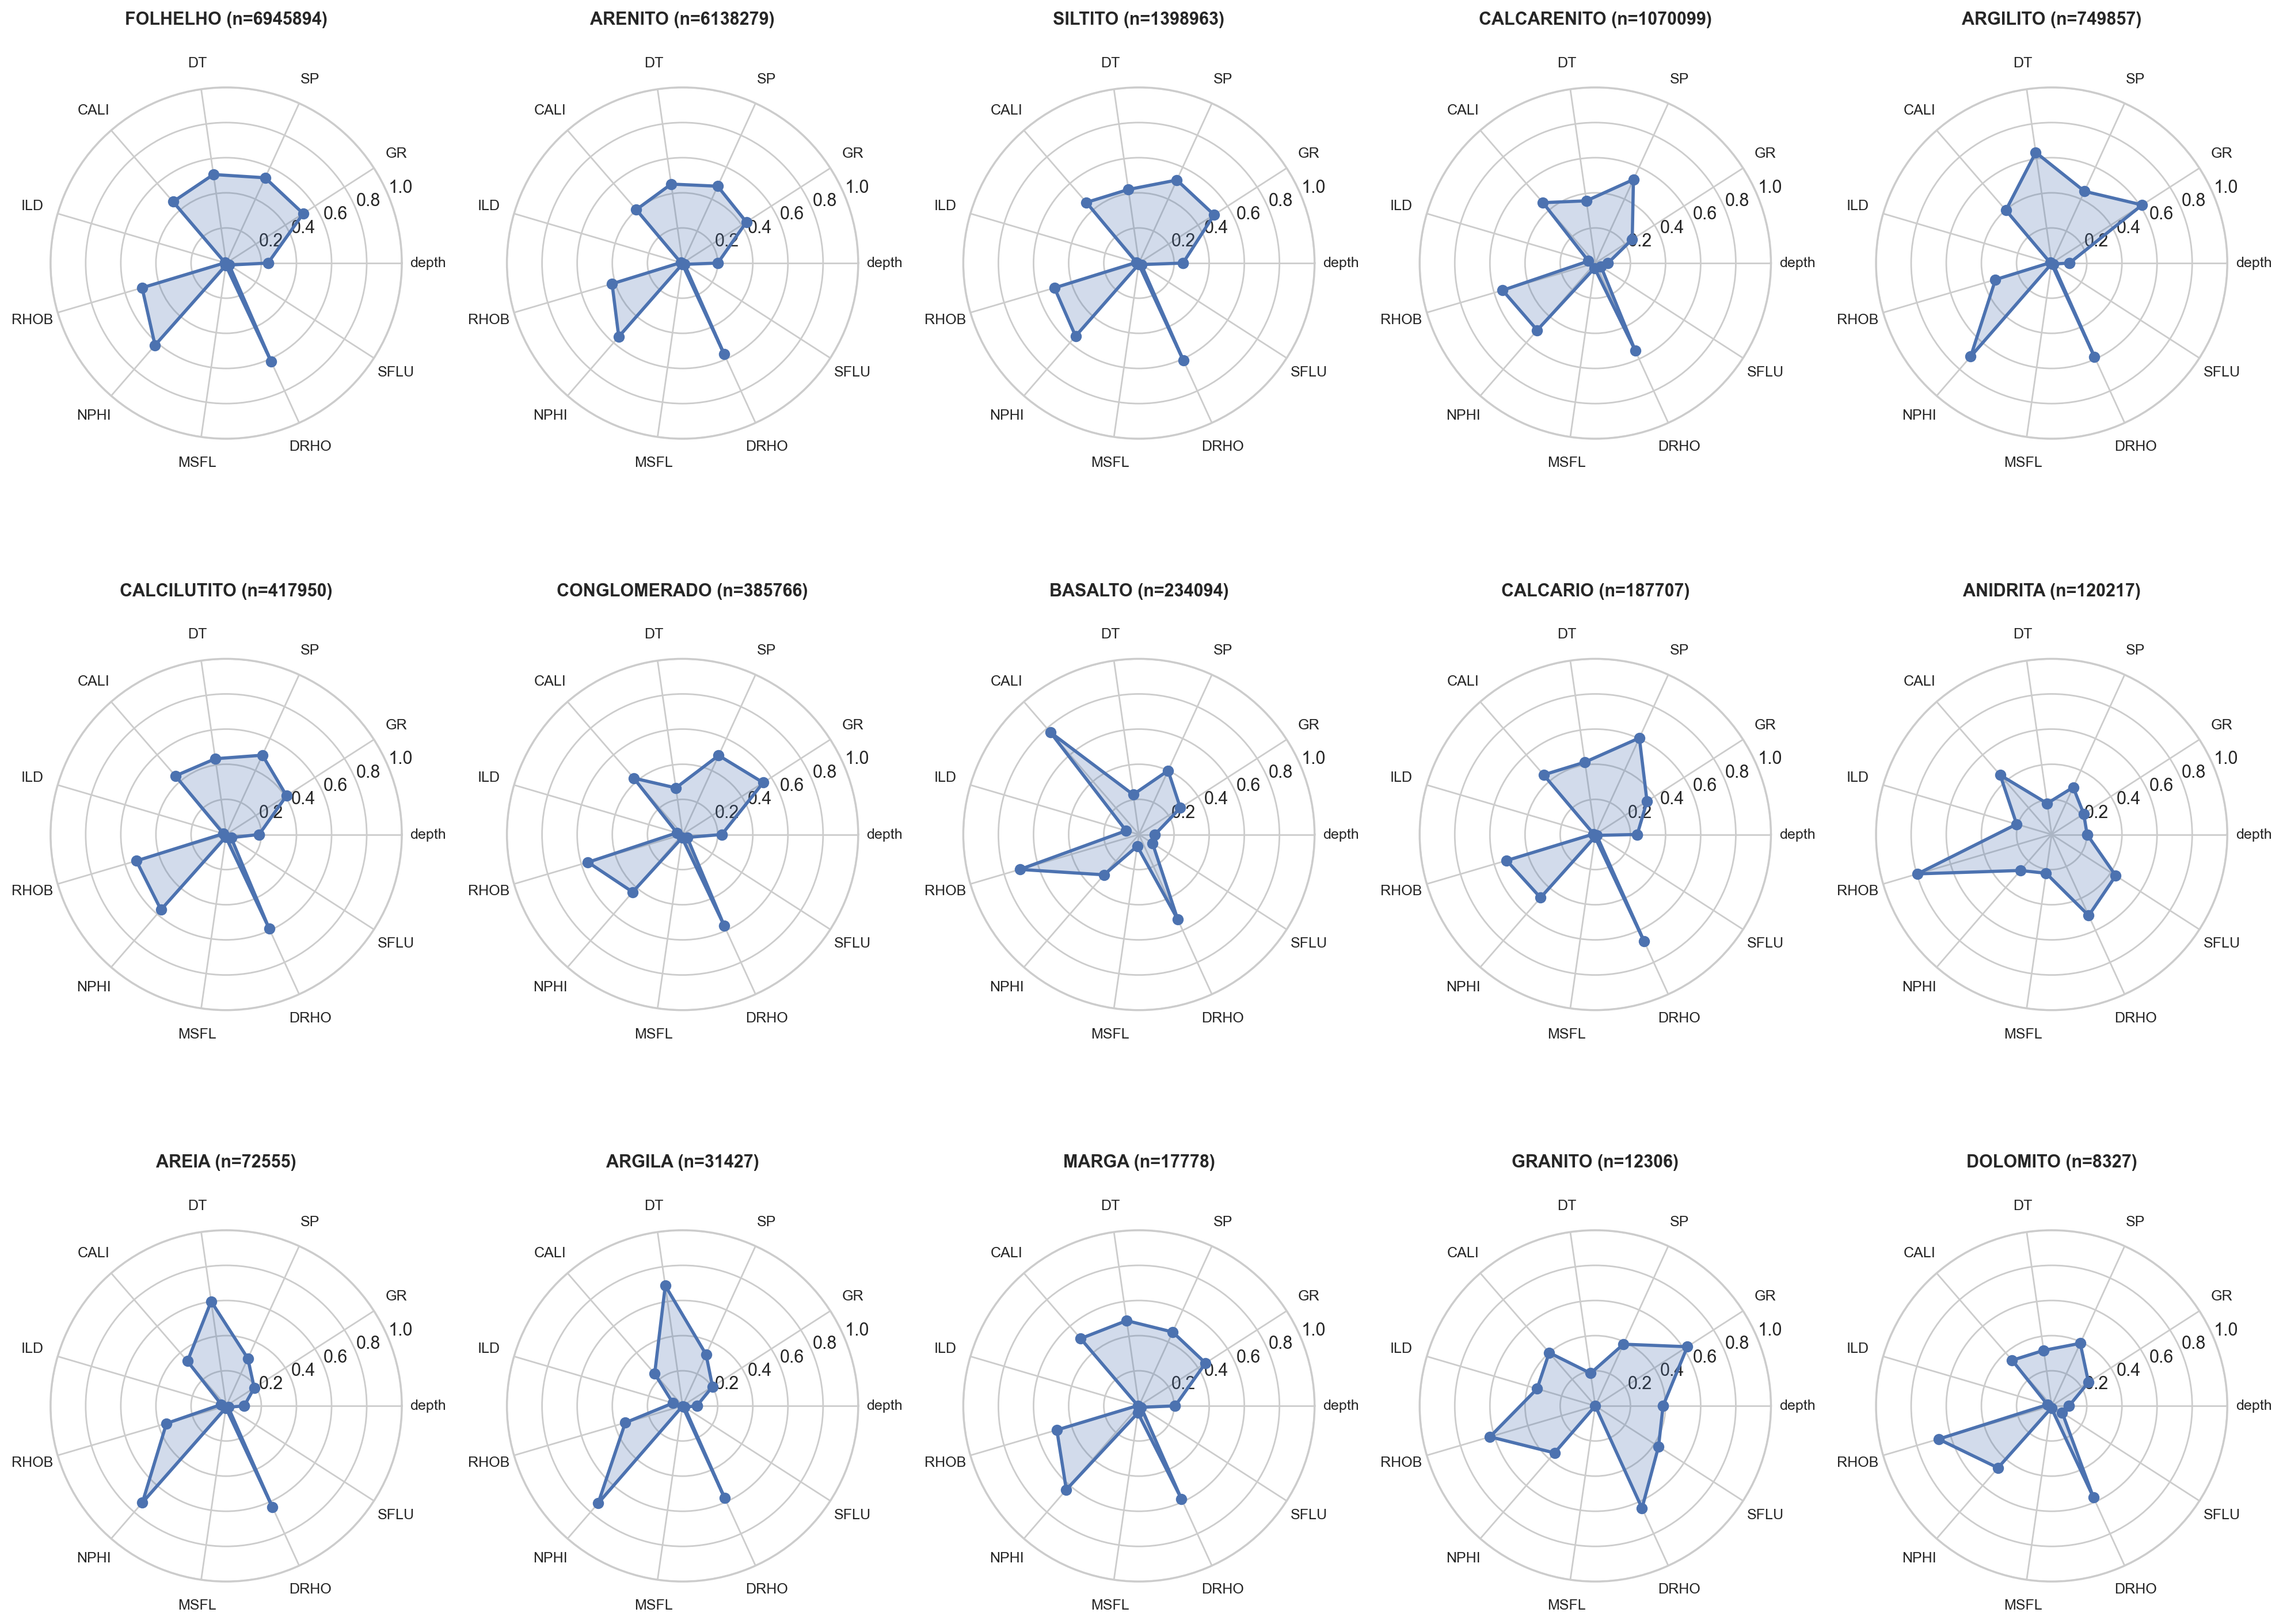

In [200]:
# ============ 5. RADAR/SPIDER PLOTS - Compare Feature Profiles ============
from math import pi
sns.set_theme(context='notebook', style='whitegrid', palette='deep', font='sans-serif', font_scale=1, color_codes=True, rc=None)

# Select rocks with most samples for clarity
rock_counts = df_features_filtered[target_column].value_counts()
top_rocks = rock_counts.head(15).index.tolist()  # Top 15 rocks

# Normalize features (0-1) for radar plot
df_radar = df_features_filtered[df_features_filtered[target_column].isin(top_rocks)].copy()
for col in analysis_features:
    col_min = df_radar[col].min()
    col_max = df_radar[col].max()
    if col_max > col_min:
        df_radar[col] = (df_radar[col] - col_min) / (col_max - col_min)
    else:
        df_radar[col] = 0.5

# Calculate mean noarmalized values for each rock
mean_normalized = df_radar.groupby(target_column)[analysis_features].mean()

# Create subplots for radar charts
n_rocks = len(top_rocks)
n_cols = 5
n_rows = (n_rocks + 4) // 3

fig = plt.figure(figsize=(20, 5 * n_rows), dpi=200)
#fig.suptitle('Feature Profiles by Rock Type (Radar Charts - Normalized 0-1)', 
#             fontsize=16, fontweight='bold', y=1)

angles = [n / len(analysis_features) * 2 * pi for n in range(len(analysis_features))]
angles += angles[:1]  # Complete the circle

for idx, rock in enumerate(top_rocks):
    ax = plt.subplot(n_rows, n_cols, idx + 1, projection='polar')
    
    values = mean_normalized.loc[rock, analysis_features].tolist()
    values += values[:1]  # Complete the circle
    
    ax.plot(angles, values, 'o-', linewidth=2, label=rock)
    ax.fill(angles, values, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(analysis_features, size=9)
    ax.set_ylim(0, 1)
    ax.set_title(f'{rock} (n={len(df_features_filtered[df_features_filtered[target_column]==rock])})', 
                fontsize=11, fontweight='bold', pad=20)
    ax.grid(True)

plt.tight_layout()
plt.show()



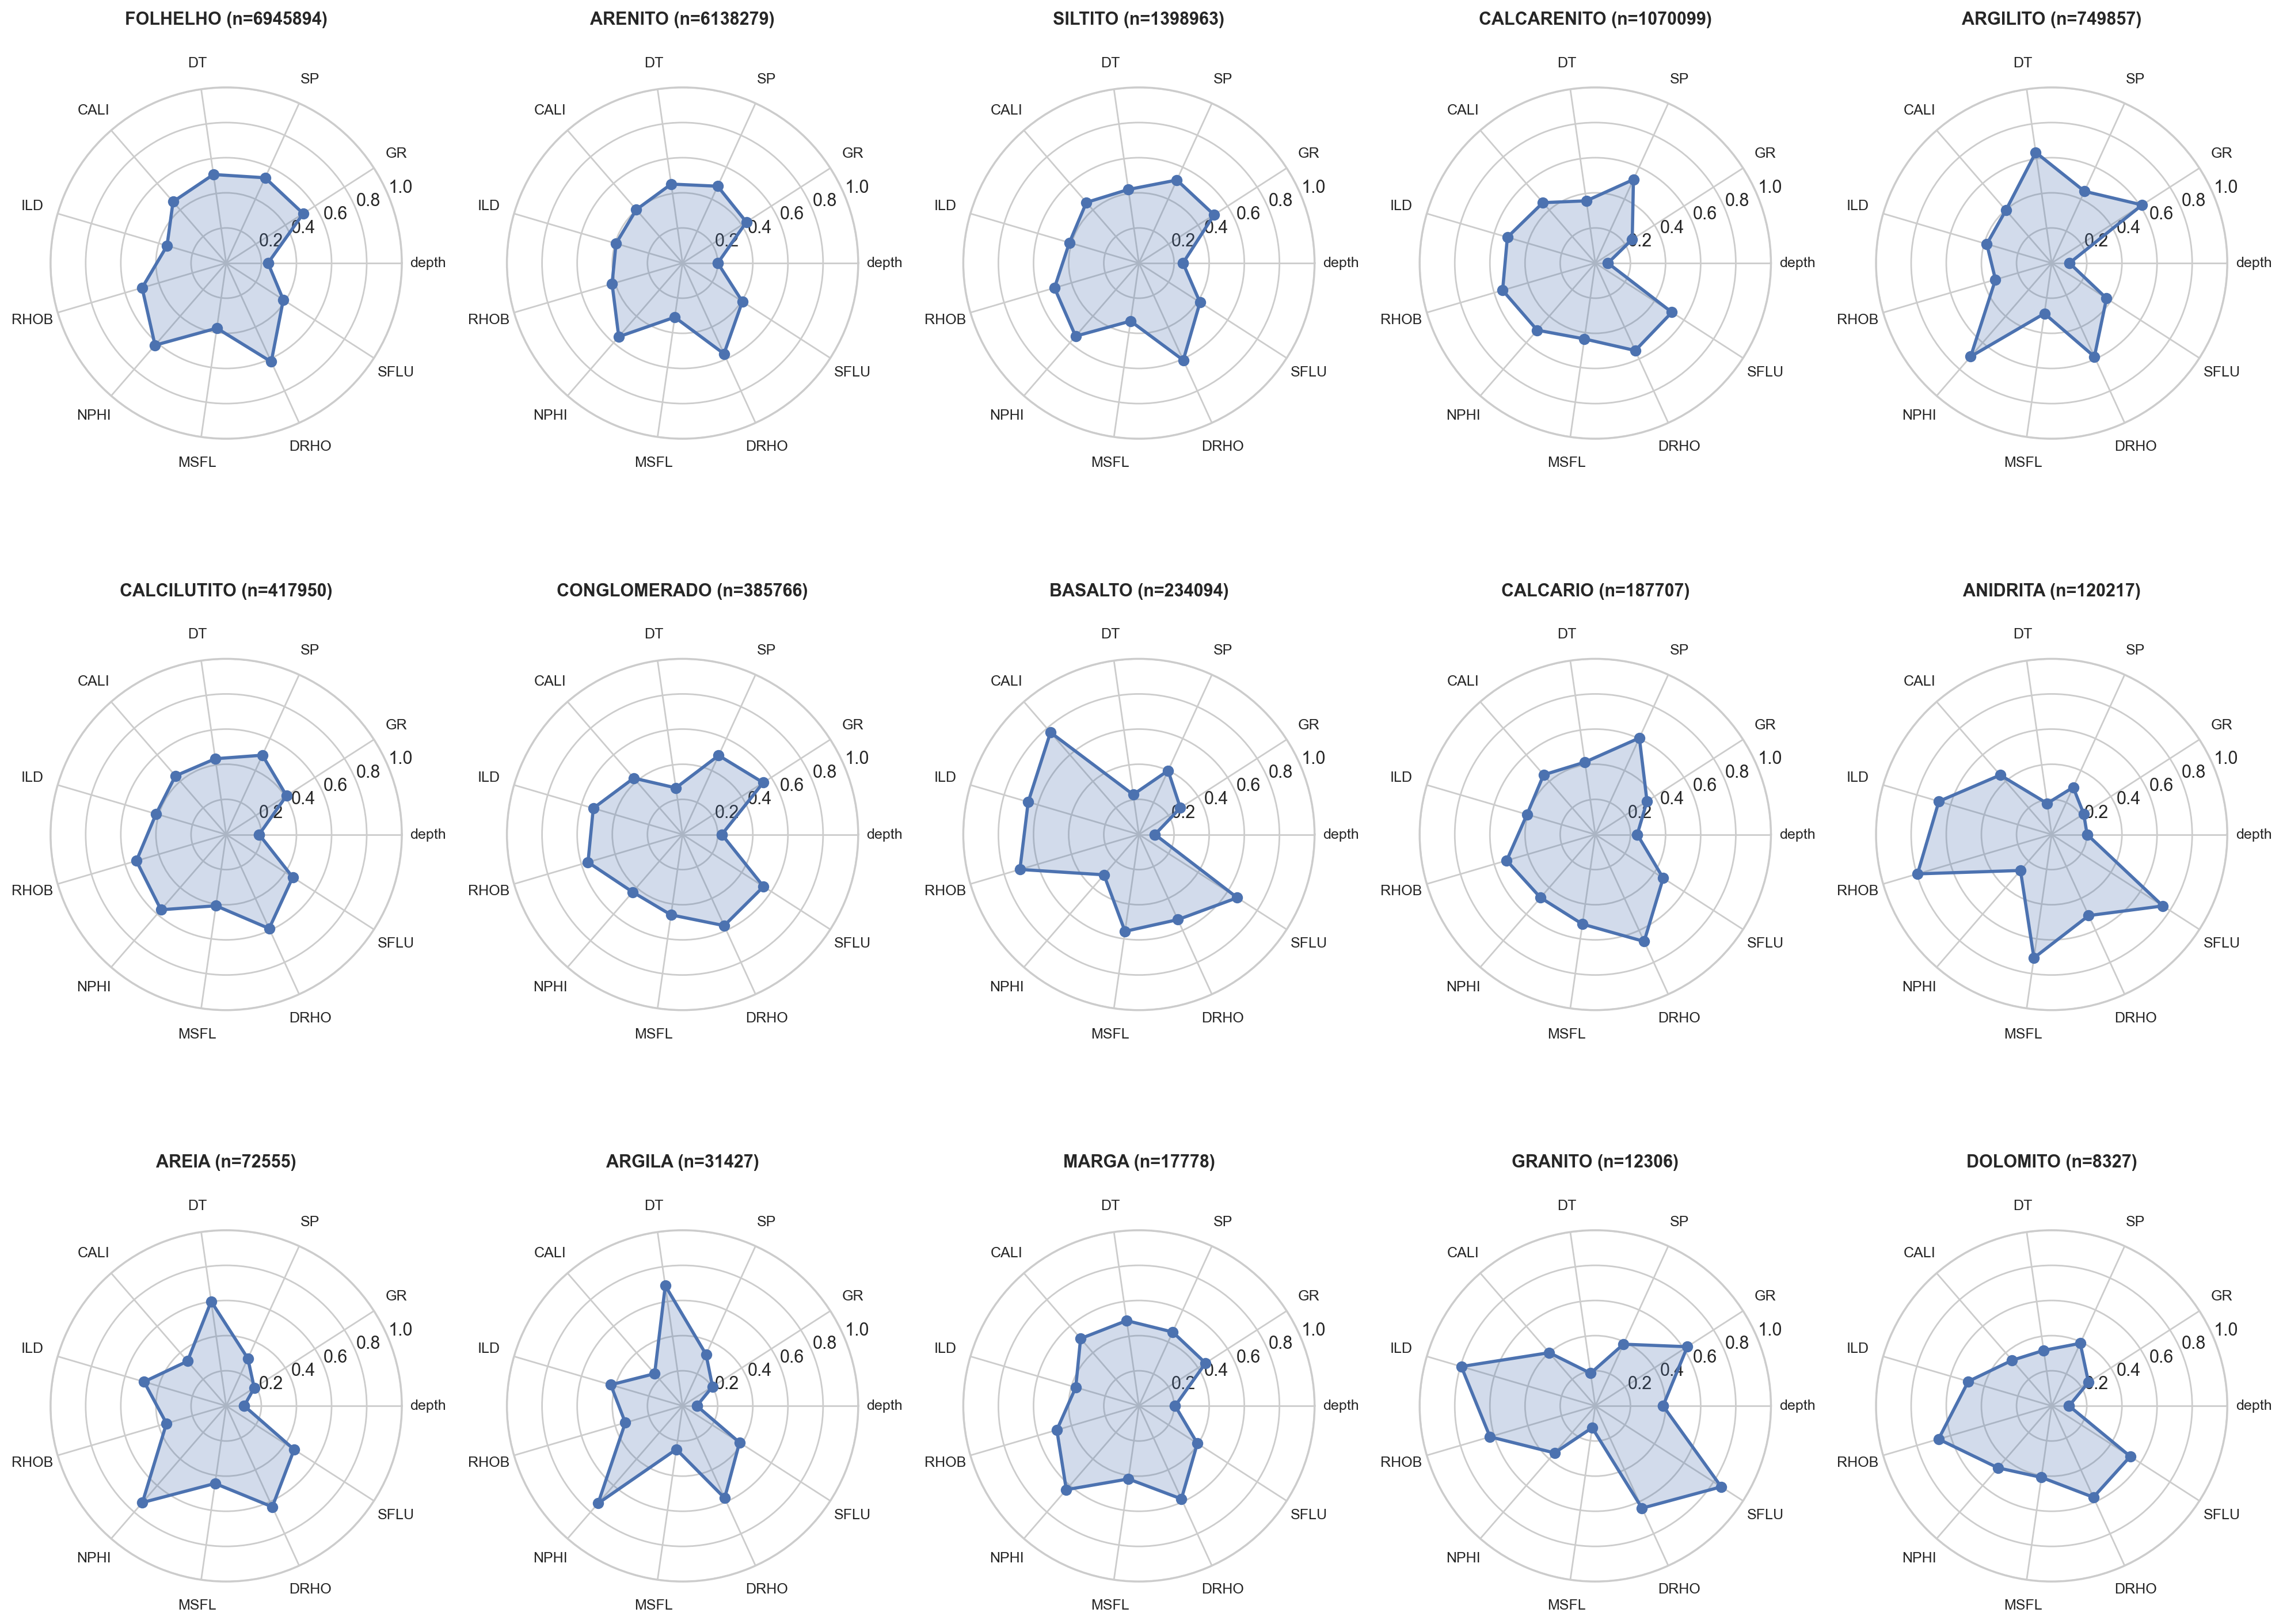

In [233]:
# ============ 5. RADAR/SPIDER PLOTS - Compare Feature Profiles ============
from math import pi
sns.set_theme(context='notebook', style='whitegrid', palette='deep', font='sans-serif', font_scale=1, color_codes=True, rc=None)

# Select rocks with most samples for clarity
rock_counts = df_features_filtered[target_column].value_counts()
top_rocks = rock_counts.head(15).index.tolist()  # Top 15 rocks

# Normalize features (0-1) for radar plot
df_radar = df_features_filtered[df_features_filtered[target_column].isin(top_rocks)].copy()
for col in analysis_features:
    col_min = df_radar[col].min()
    col_max = df_radar[col].max()
    if col_max > col_min:
        df_radar[col] = (df_radar[col] - col_min) / (col_max - col_min)
    else:
        df_radar[col] = 0.5

# Calculate mean noarmalized values for each rock
mean_normalized = df_radar.groupby(target_column)[analysis_features].mean()

# Create subplots for radar charts
n_rocks = len(top_rocks)
n_cols = 5
n_rows = (n_rocks + 4) // 3

fig = plt.figure(figsize=(20, 5 * n_rows), dpi=200)
#fig.suptitle('Feature Profiles by Rock Type (Radar Charts - Normalized 0-1)', 
#             fontsize=16, fontweight='bold', y=1)

angles = [n / len(analysis_features) * 2 * pi for n in range(len(analysis_features))]
angles += angles[:1]  # Complete the circle

for idx, rock in enumerate(top_rocks):
    ax = plt.subplot(n_rows, n_cols, idx + 1, projection='polar')
    
    values = mean_normalized.loc[rock, analysis_features].tolist()
    values += values[:1]  # Complete the circle
    
    ax.plot(angles, values, 'o-', linewidth=2, label=rock)
    ax.fill(angles, values, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(analysis_features, size=9)
    ax.set_ylim(0, 1)
    ax.set_title(f'{rock} (n={len(df_features_filtered[df_features_filtered[target_column]==rock])})', 
                fontsize=11, fontweight='bold', pad=20)
    ax.grid(True)

plt.tight_layout()
plt.show()



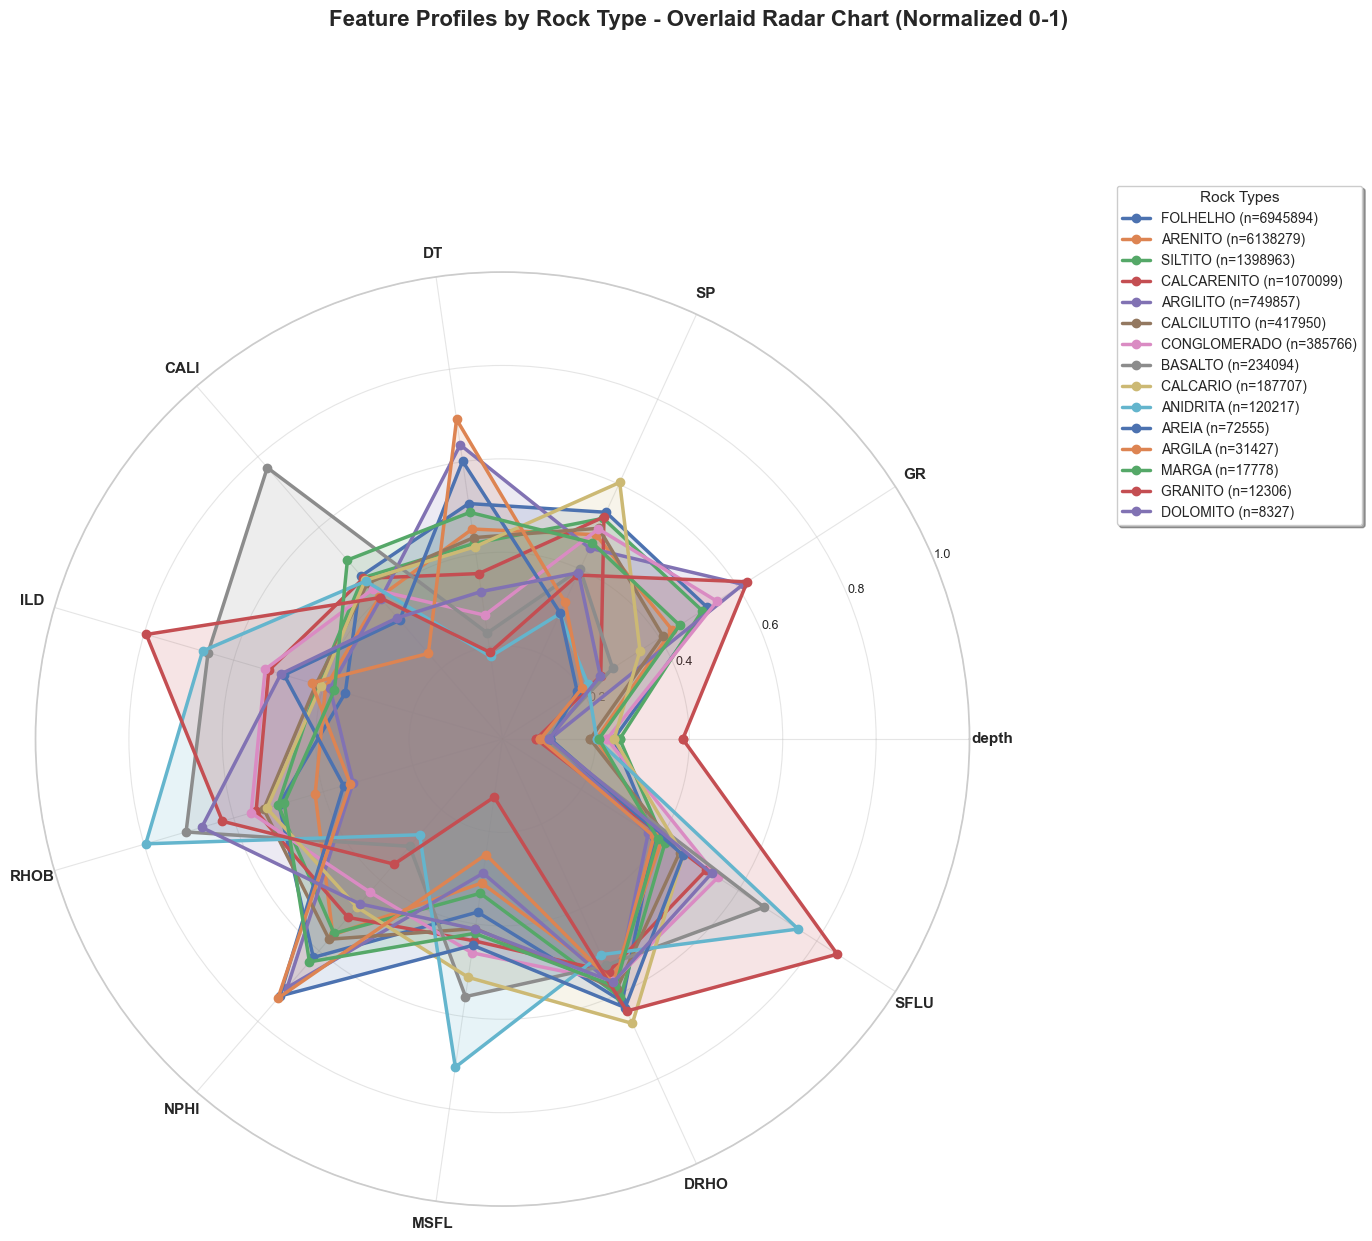

In [103]:
# ============ 5. RADAR/SPIDER PLOTS - Compare Feature Profiles ============
from math import pi

# Select rocks with most samples for clarity
rock_counts = df_features_filtered[target_column].value_counts()
top_rocks = rock_counts.head(15).index.tolist()  # Top 15 rocks

# Normalize features (0-1) for radar plot
df_radar = df_features_filtered[df_features_filtered[target_column].isin(top_rocks)].copy()
for col in analysis_features:
    col_min = df_radar[col].min()
    col_max = df_radar[col].max()
    if col_max > col_min:
        df_radar[col] = (df_radar[col] - col_min) / (col_max - col_min)
    else:
        df_radar[col] = 0.5

# Calculate mean normalized values for each rock
mean_normalized = df_radar.groupby(target_column)[analysis_features].mean()

# Create a single overlaid radar chart with all rocks
fig, ax = plt.subplots(figsize=(14, 14), subplot_kw=dict(projection='polar'))

fig.suptitle('Feature Profiles by Rock Type - Overlaid Radar Chart (Normalized 0-1)', 
             fontsize=16, fontweight='bold', y=0.98)

angles = [n / len(analysis_features) * 2 * pi for n in range(len(analysis_features))]
angles += angles[:1]  # Complete the circle

# Create a color palette for the rocks
#colors = plt.cm.tab20(np.linspace(0, 1, len(top_rocks)))

# Plot each rock on the same radar chart
for idx, rock in enumerate(top_rocks):
    values = mean_normalized.loc[rock, analysis_features].tolist()
    values += values[:1]  # Complete the circle
    
    ax.plot(angles, values, 'o-', linewidth=2.5, label=f'{rock} (n={len(df_features_filtered[df_features_filtered[target_column]==rock])})', 
            )
    ax.fill(angles, values, alpha=0.15, )

# Configure the radar chart
ax.set_xticks(angles[:-1])
ax.set_xticklabels(analysis_features, size=11, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], size=9)
ax.grid(True, linewidth=0.8, alpha=0.5)

# Add legend outside the plot
ax.legend(loc='upper left', bbox_to_anchor=(1.15, 1.1), fontsize=10, 
          title='Rock Types', title_fontsize=11, frameon=True, fancybox=True, shadow=True)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
from slide.models.lstm import LSTM
from slide.models.featurePolicy import DefaultFeatures
from slide.logger import Logger


logging = Logger()
logging.set_level('DEBUG')
# -----------------------------
# 1) Load label_encoder from pkl
# -----------------------------
pkl_path = "../slide/models/checkpoints/lstm-policy-presence-1665-wells.pkl"
model = LSTM(hidden_size=256,
  num_layers=2,
  dropout=0.3,
  batch_size=512,
  learning_rate=0.001,
  num_workers=2)
model.load(pkl_path)

data_policy = DefaultFeatures(apply_scaling=True, apply_presence=True, apply_rolling_stats=False, test_size=0.2, random_state=42, labels=[
    'ARENITO',
    'FOLHELHO',
    'SILTITO',
    'CALCILUTITO',
    'CALCARENITO',
    'ARGILITO',
    'CALCARIO',
    'CONGLOMERADO',
    'DIABASIO',
    'ANIDRITA',
    'AREIA',
    'DIAMICTITO',
    'MARGA',
    'ARGILA',
    'DOLOMITO'
])

data = data_policy.fetch()

# Evaluate the model
results = model.evaluate(data)

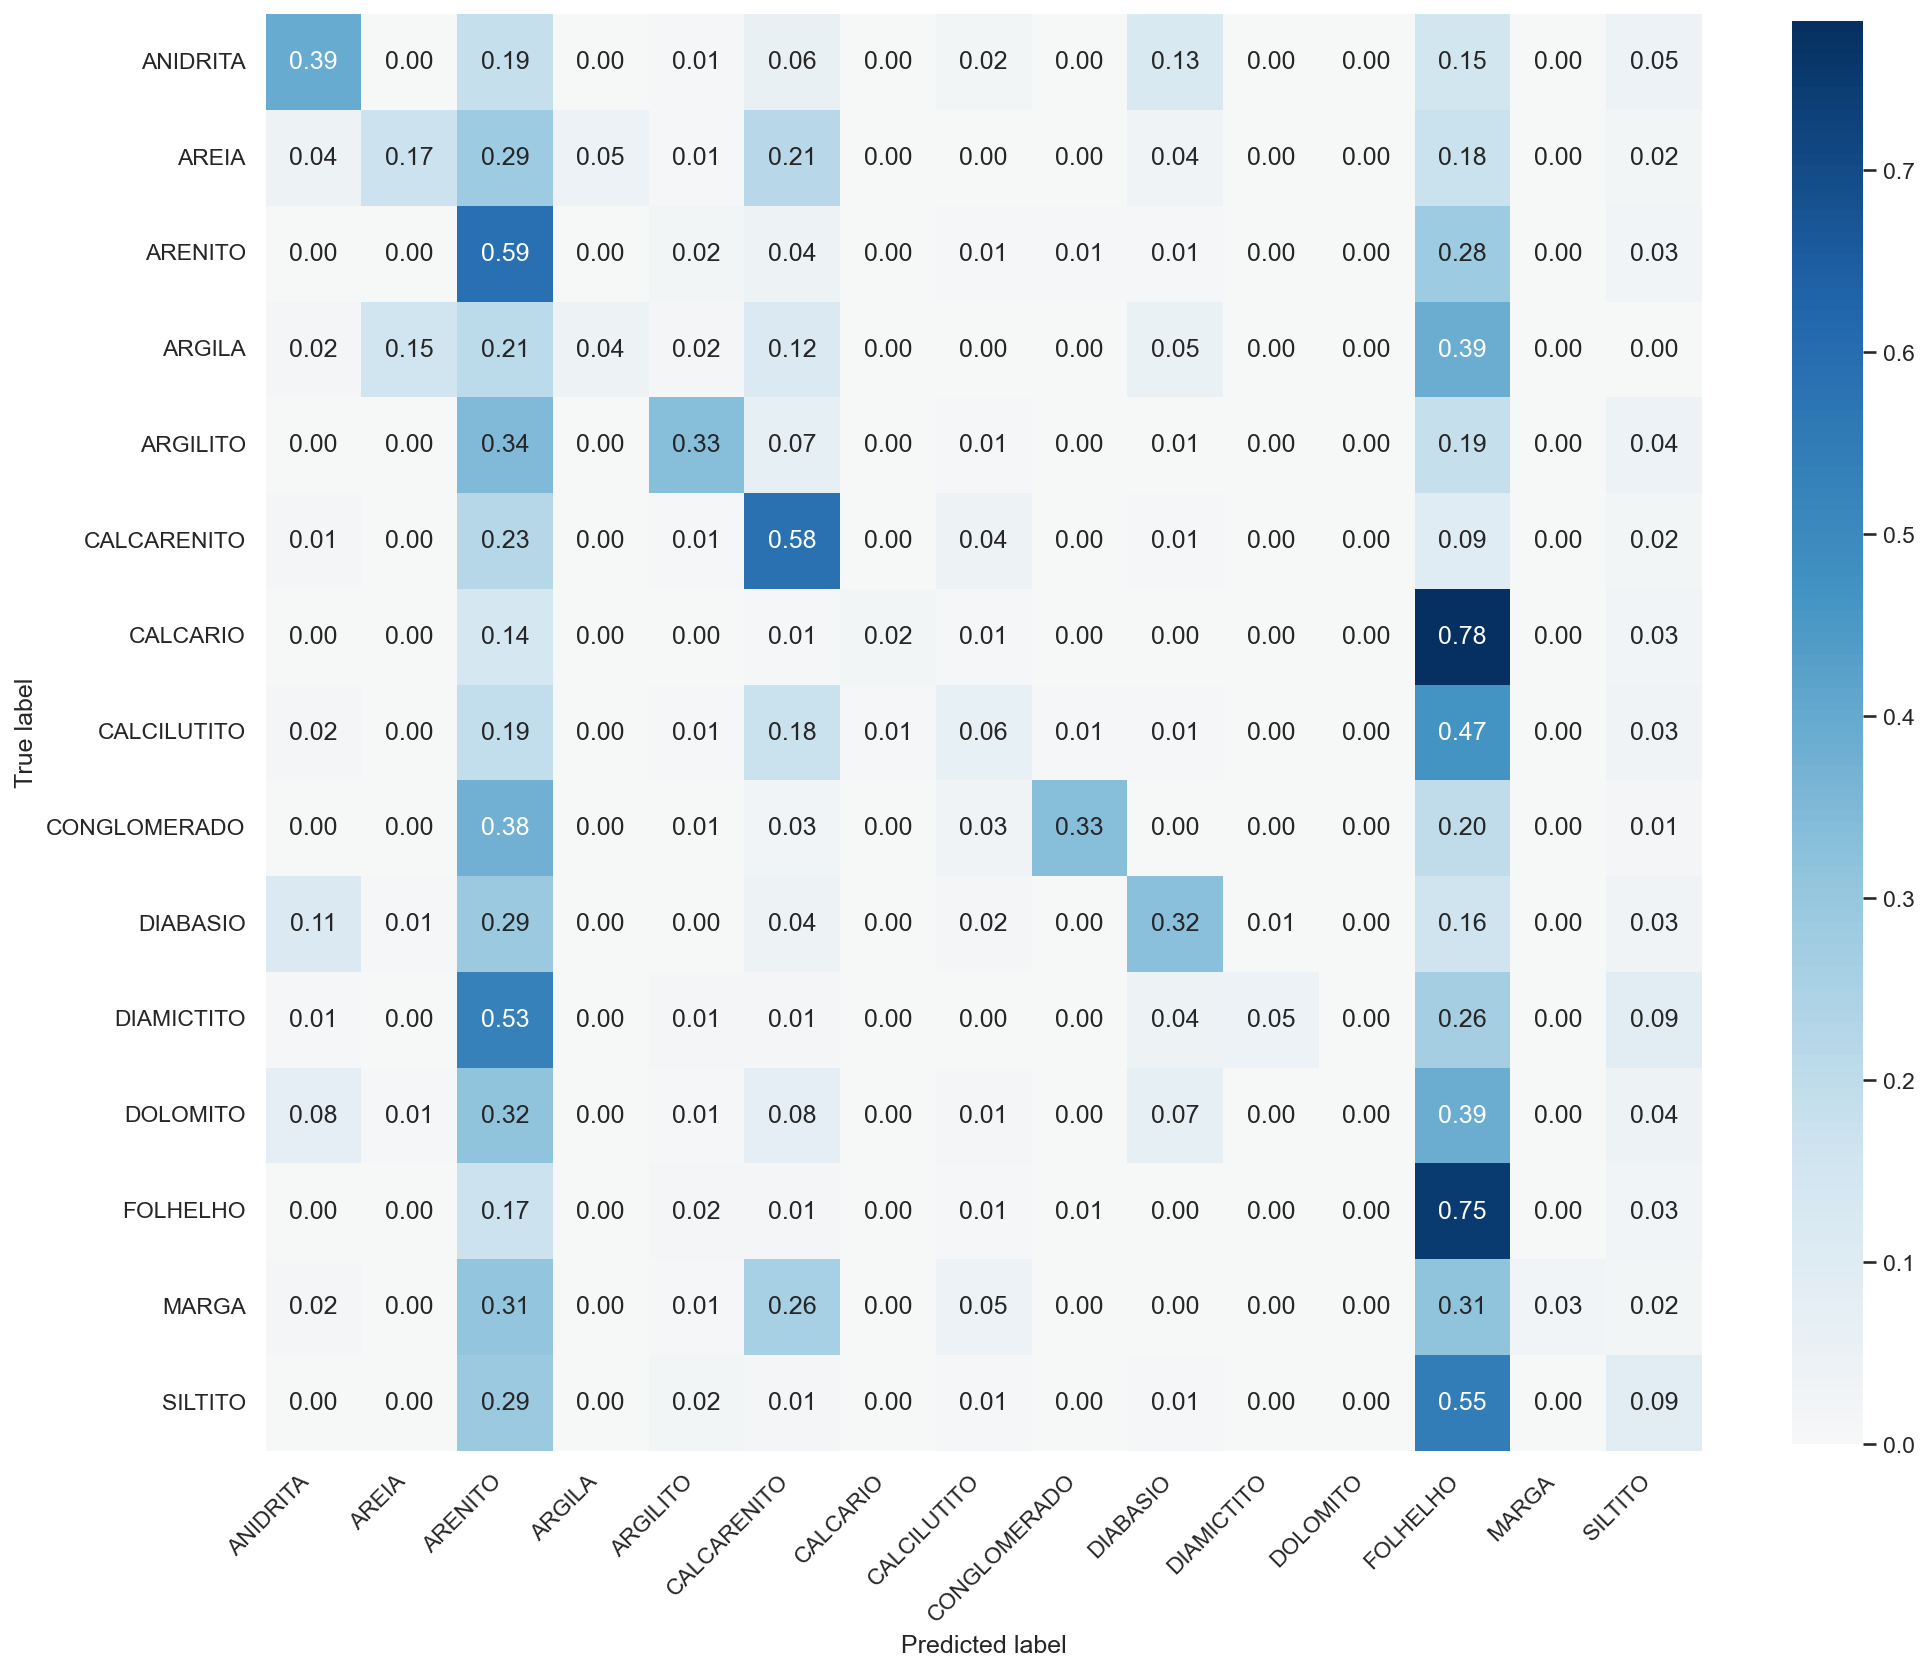

In [135]:
import seaborn as sns
sns.set_theme(context='notebook', style='whitegrid', palette='deep', font='sans-serif', font_scale=1, color_codes=True, rc=None)

cm = np.array(results["confusion_matrix"], dtype=np.int64)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)  # in case a row sum is 0

class_names = model.label_encoder.classes_
n_classes = len(class_names)
assert cm.shape == (n_classes, n_classes), f"Confusion matrix shape {cm.shape} != ({n_classes}, {n_classes})"

fig, ax = plt.subplots(figsize=(14, 12), dpi=150)
#sns.set_palette("husl")
sns.heatmap(
    cm_norm, 
    ax=ax, 
    cmap='RdBu', 
    cbar=True, 
    cbar_kws={'shrink': 0.9},
    square=True,
    center=0,
    xticklabels=class_names, 
    yticklabels=class_names,
    annot=True, 
    fmt=".2f", 
    annot_kws={"size": 12},
    edgecolor='black',
    #linecolor='black',
    #linewidths=0.01
)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

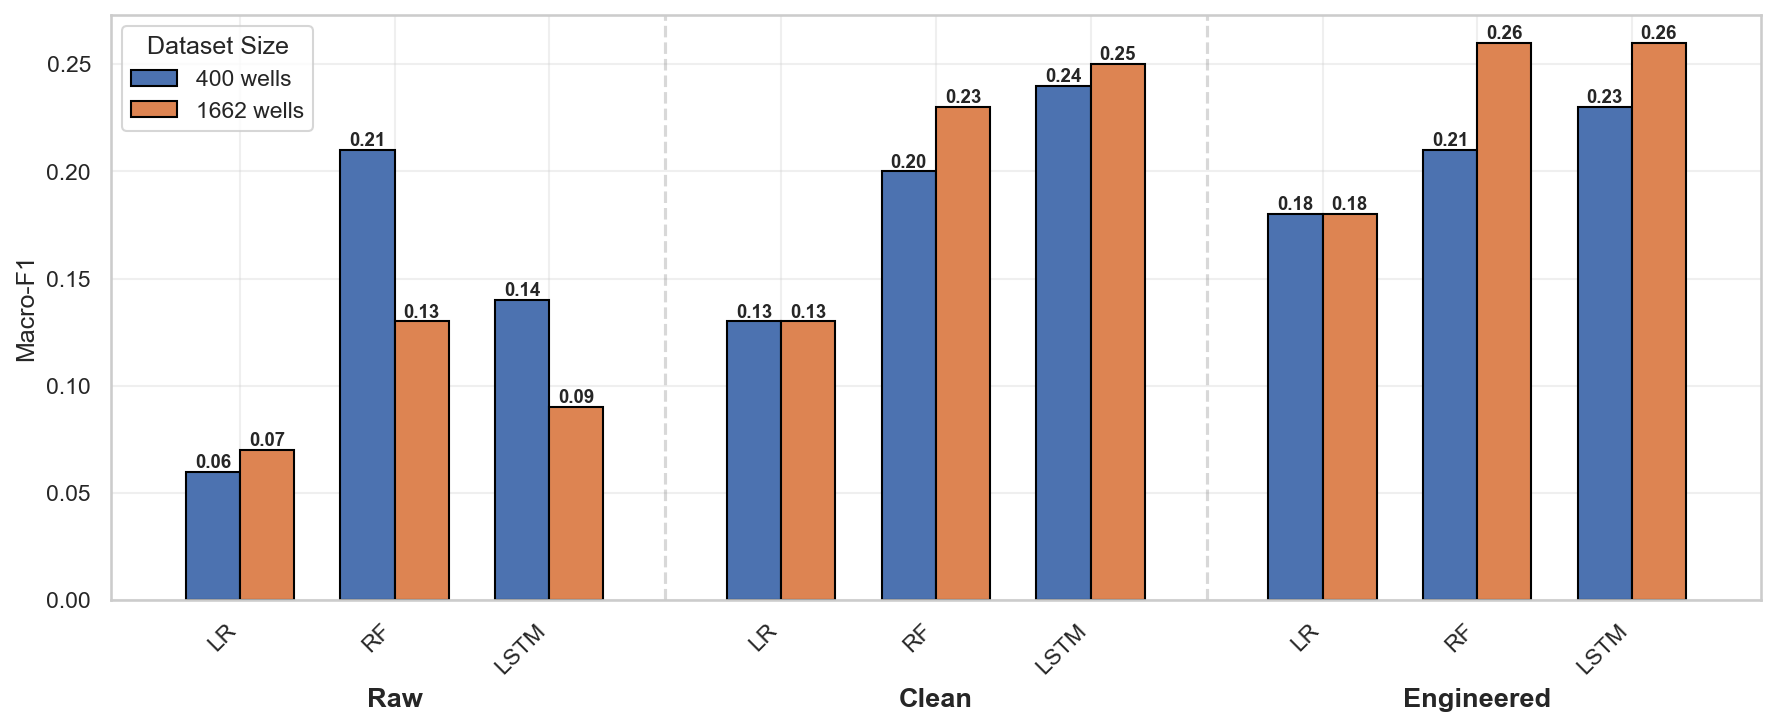

In [180]:
import matplotlib.pyplot as plt
import numpy as np

# Data extracted from the user's results
models = ["LR", "RF", "LSTM"]
representations = ["Raw", "Clean", "Engineered"]  # Engineered = Rolling for LR/RF, Presence for LSTM

# Macro-F1 values
f1_400 = {
    "LR": [0.06, 0.13, 0.18],   # Raw, Clean, Rolling 10
    "RF": [0.21, 0.20, 0.21],         # Raw, Clean, Rolling 10
    "LSTM": [0.14, 0.24, 0.23],                  # Raw, Clean, Presence
}

f1_1662 = {
    "LR": [0.07, 0.13, 0.18],   # Raw, Clean, Rolling 10
    "RF": [0.13, 0.23, 0.26],         # Raw, Clean, Rolling 10
    "LSTM": [0.09, 0.25, 0.26],                  # Raw, Clean, Presence
}

# Restructure data: group by representation first, then model
vals_400 = []
vals_1662 = []
model_labels = []

for r in representations:
    rep_idx = representations.index(r)
    for m in models:
        vals_400.append(f1_400[m][rep_idx])
        vals_1662.append(f1_1662[m][rep_idx])
        model_labels.append(m)

# Create x positions with spacing between representation groups
n_models = len(models)
n_reps = len(representations)
group_spacing = 0.5  # Extra space between representation groups

x_positions = []
for i in range(n_reps):
    for j in range(n_models):
        x_positions.append(i * (n_models + group_spacing) + j)

x_positions = np.array(x_positions)
bar_width = 0.35

# Create plot
fig, ax = plt.subplots(figsize=(12, 5), dpi=150)
ax.bar(x_positions - bar_width/2, vals_400, bar_width, label="400 wells", edgecolor='black')
ax.bar(x_positions + bar_width/2, vals_1662, bar_width, label="1662 wells", edgecolor='black')
ax.grid(True, alpha=0.3)
# Add value labels on top of each bar
for i, (x_pos, val_400, val_1662) in enumerate(zip(x_positions, vals_400, vals_1662)):
    # Label for 400 wells bar
    ax.text(x_pos - bar_width/2, val_400, f'{val_400:.2f}', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')
    # Label for 1662 wells bar
    ax.text(x_pos + bar_width/2, val_1662, f'{val_1662:.2f}', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Set x-axis labels (model names)
ax.set_xticks(x_positions)
ax.set_xticklabels(model_labels, rotation=45, ha="right")
ax.set_ylabel("Macro-F1")
#ax.set_title("Macro-F1 by Feature Representation and Dataset Size\n(Hyperparameters fixed from 400-well tuning)")
ax.legend(title="Dataset Size", loc='upper left')

# Add representation labels as bold text below the x-axis
for i, rep in enumerate(representations):
    # Calculate center position of each representation group
    group_center = i * (n_models + group_spacing) + (n_models - 1) / 2
    ax.text(group_center, -0.15, rep, ha='center', va='top', 
            transform=ax.get_xaxis_transform(), fontsize=13, fontweight='bold')

# Add vertical lines to separate representation groups
for i in range(1, n_reps):
    sep_pos = i * (n_models + group_spacing) - (group_spacing + 1) / 2
    ax.axvline(x=sep_pos, color='gray', linestyle='--', alpha=0.3, linewidth=1.5)

plt.tight_layout()
plt.show()


## Dataset Summary

- Total wells by is_labeled
    - Pie chart
    - Slices: Labeled vs Unlabeled
- Distribution of wells by basin and is_labeled
    - Stacked bar chart
    - X-axis: Basins
    - Y-axis: Distinct Number of wells
    - Different colors for each file type (is_labeled)
    - on top of each bar: percentage of total wells in that basin
- Distribution of wells by Lithology
    - Bar chart
    - X-axis: Lithology
    - Y-axis: Distinct Number of wells
    - on top of each bar: percentage of total wells with that lithology
- Distribution of missing data by log type
    - Stacked Bar chart
    - X-axis: Log Types
    - Y-axis: Total rows
    - Legend: Missing vs Non-Missing
    - On top of each bar: percentage of missing data for that log type
- Correlation matrix of log types
    - Heatmap
    - Color scale indicating correlation strength


- Normal distribution plots for each log type
    - Subplots for each log type
    - X-axis: Log Values
    - Y-axis: Density
- Distribution of log values by log type
    - Subplots with Box plots for each log type
    - X-axis: Log Types
    - Y-axis: Log Values


In [95]:
############## wells, basins and is labeled distribution ##############

import os
import pandas as pd
import sqlite3

conn = sqlite3.connect('../slide/database/download.db')
conn.enable_load_extension(True)
conn.load_extension(f"../slide/database/models/regex0.{'dll' if os.name == 'nt' else 'so'}")

query = """
 WITH LabeledWells AS (
    SELECT DISTINCT
        replace(
            regex_replace(
                '([A-Za-z]*|^0[0-9])0+([A-Za-z0-9])',
                a.well,'$1$2'),
            " ", "") AS well,
        "labeled" AS labeled
    FROM AGPLithology a
    WHERE a.well IS NOT NULL
),
NotLabeledWells AS (
    SELECT DISTINCT
        replace(well,"-","") AS well,
        basin
    FROM logs
)
SELECT
    COUNT(DISTINCT well) AS Wells_Count,
    basin,
    CASE WHEN labeled IS NULL THEN "not labeled" ELSE "labeled" END AS labeled_status
FROM NotLabeledWells LEFT JOIN LabeledWells USING (well)
GROUP BY 2, 3
ORDER BY 1 DESC;
"""
df_wells = pd.read_sql_query(query, conn)
df_wells.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Wells_Count     35 non-null     int64 
 1   basin           35 non-null     object
 2   labeled_status  35 non-null     object
dtypes: int64(1), object(2)
memory usage: 972.0+ bytes


### General dataset statistics

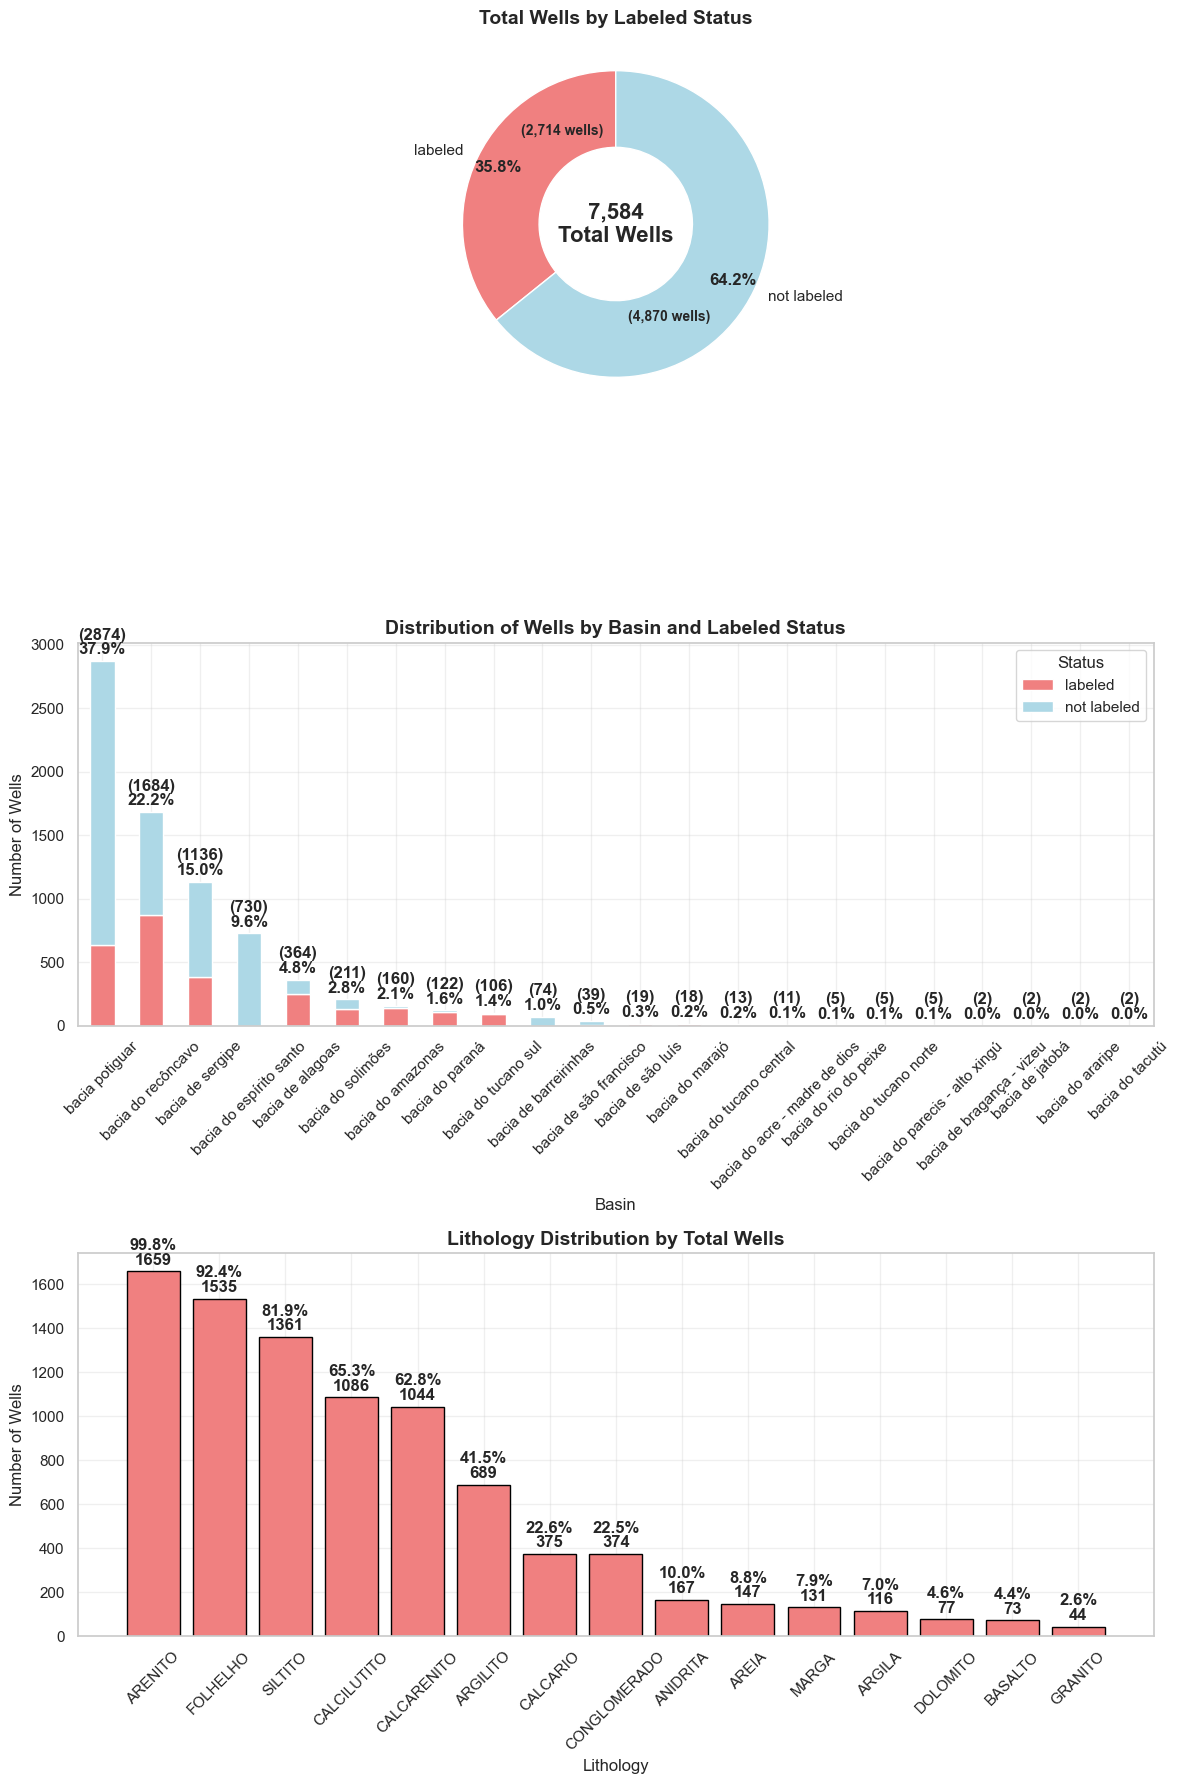

In [96]:
import numpy as np

import matplotlib.pyplot as plt

############################# WELLS DISTRIBUTION CHARTS ##########################
# 1. Pie chart for total wells by labeled_status
labeled_totals = df_wells.groupby('labeled_status')['Wells_Count'].sum()
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# Donut chart - first row
ax1 = axes[0]
colors = ['lightcoral', 'lightblue']
wedges, texts, autotexts = ax1.pie(labeled_totals.values, labels=labeled_totals.index, 
                                   autopct='%1.1f%%', colors=colors, startangle=90,
                                   pctdistance=0.85, wedgeprops=dict(width=0.5))
ax1.set_title('Total Wells by Labeled Status', fontsize=14, fontweight='bold')

# Make percentage text bold
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

# Add total wells count in the center
total_wells = labeled_totals.sum()
ax1.text(0, 0, f'{total_wells:,}\nTotal Wells', ha='center', va='center', 
         fontsize=16, fontweight='bold')

# Add well counts below percentages
for i, (label, count) in enumerate(labeled_totals.items()):
    angle = 120 + (i * 180)  # Position text radially
    x = 0.7 * np.cos(np.radians(angle))
    y = 0.7 * np.sin(np.radians(angle))
    ax1.text(x, y, f'({count:,} wells)', ha='center', va='center', 
             fontsize=10, fontweight='bold')

# 2. Stacked bar chart for distribution by basin and labeled_status - second row
ax2 = axes[1]
pivot_data = df_wells.pivot(index='basin', columns='labeled_status', values='Wells_Count').fillna(0)

# Calculate percentages for each basin
basin_totals = pivot_data.sum(axis=1)
pivot_percentages = pivot_data.div(basin_totals, axis=0) * 100

# Sort by total wells (descending order)
pivot_data_sorted = pivot_data.loc[basin_totals.sort_values(ascending=False).index]
basin_totals_sorted = basin_totals.sort_values(ascending=False)

# Create stacked bar chart
pivot_data_sorted.plot(kind='bar', stacked=True, ax=ax2, color=['lightcoral', 'lightblue'])
ax2.set_title('Distribution of Wells by Basin and Labeled Status', fontsize=14, fontweight='bold')
ax2.set_xlabel('Basin')
ax2.set_ylabel('Number of Wells')
ax2.tick_params(axis='x', rotation=45)
ax2.legend(title='Status')
ax2.grid(True, alpha=0.3)

# Add percentage labels on top of each bar
for i, (basin, total) in enumerate(basin_totals_sorted.items()):
    percentage = (total / labeled_totals.sum()) * 100
    ax2.text(i, total + max(basin_totals_sorted) * 0.01, f'{percentage:.1f}%', 
             ha='center', va='bottom', fontweight='bold')
    ax2.text(i, total + max(basin_totals_sorted) * 0.05, f'({int(total)})', 
             ha='center', va='bottom', fontweight='bold')

########################## LITHOLOGY DISTRIBUTION CHART ##########################

# Count distinct wells for each rock type
rock_well_counts = df_features_filtered.groupby(target_column)['well'].nunique().sort_values(ascending=False)
rock_well_percentages = (rock_well_counts / df_features_filtered['well'].nunique()) * 100

# Create a summary dataframe
rock_well_distribution = pd.DataFrame({
    'Rock_Type': rock_well_counts.index,
    'Wells_Count': rock_well_counts.values,
    'Wells_Percentage': rock_well_percentages.values
})

# Bar chart for lithology distribution - third row
ax3 = axes[2]
ax3.bar(rock_well_distribution['Rock_Type'], rock_well_distribution['Wells_Count'], 
        color='lightcoral', edgecolor='black')
ax3.set_title('Lithology Distribution by Total Wells', fontsize=14, fontweight='bold')
ax3.set_xlabel('Lithology')
ax3.set_ylabel('Number of Wells')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True, alpha=0.3)

# Add count labels on bars
for i, v in enumerate(rock_well_distribution['Wells_Count']):
    ax3.text(i, v + max(rock_well_distribution['Wells_Count']) * 0.01, str(v), 
             ha='center', va='bottom', fontweight='bold')
    ax3.text(i, v + max(rock_well_distribution['Wells_Count']) * 0.05, 
             f"{rock_well_distribution['Wells_Percentage'][i]:.1f}%", 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


In [97]:
########################## SUMMARY WELLS DISTRIBUTION ##################

# Print summary statistics
print("Wells Distribution Summary:")
print("=" * 40)
print(f"Total wells: {labeled_totals.sum()}")
print(f"Labeled wells: {labeled_totals['labeled']} ({labeled_totals['labeled']/labeled_totals.sum()*100:.1f}%)")
print(f"Not labeled wells: {labeled_totals['not labeled']} ({labeled_totals['not labeled']/labeled_totals.sum()*100:.1f}%)")
print("\nTop 5 basins by total wells:")
print(basin_totals.sort_values(ascending=False).head())


########################### Lithology Distribution Summary ##########################
# Print summary statistics
print("Lithology Distribution Summary:")
print("=" * 40)
print(f"Total data points: {df_features_filtered[target_column].count():,}")

Wells Distribution Summary:
Total wells: 7584
Labeled wells: 2714 (35.8%)
Not labeled wells: 4870 (64.2%)

Top 5 basins by total wells:
basin
bacia potiguar             2874.0
bacia do recôncavo         1684.0
bacia de sergipe           1136.0
bacia do espírito santo     730.0
bacia de alagoas            364.0
dtype: float64
Lithology Distribution Summary:
Total data points: 17,791,219


### Plot Log Distribution Charts

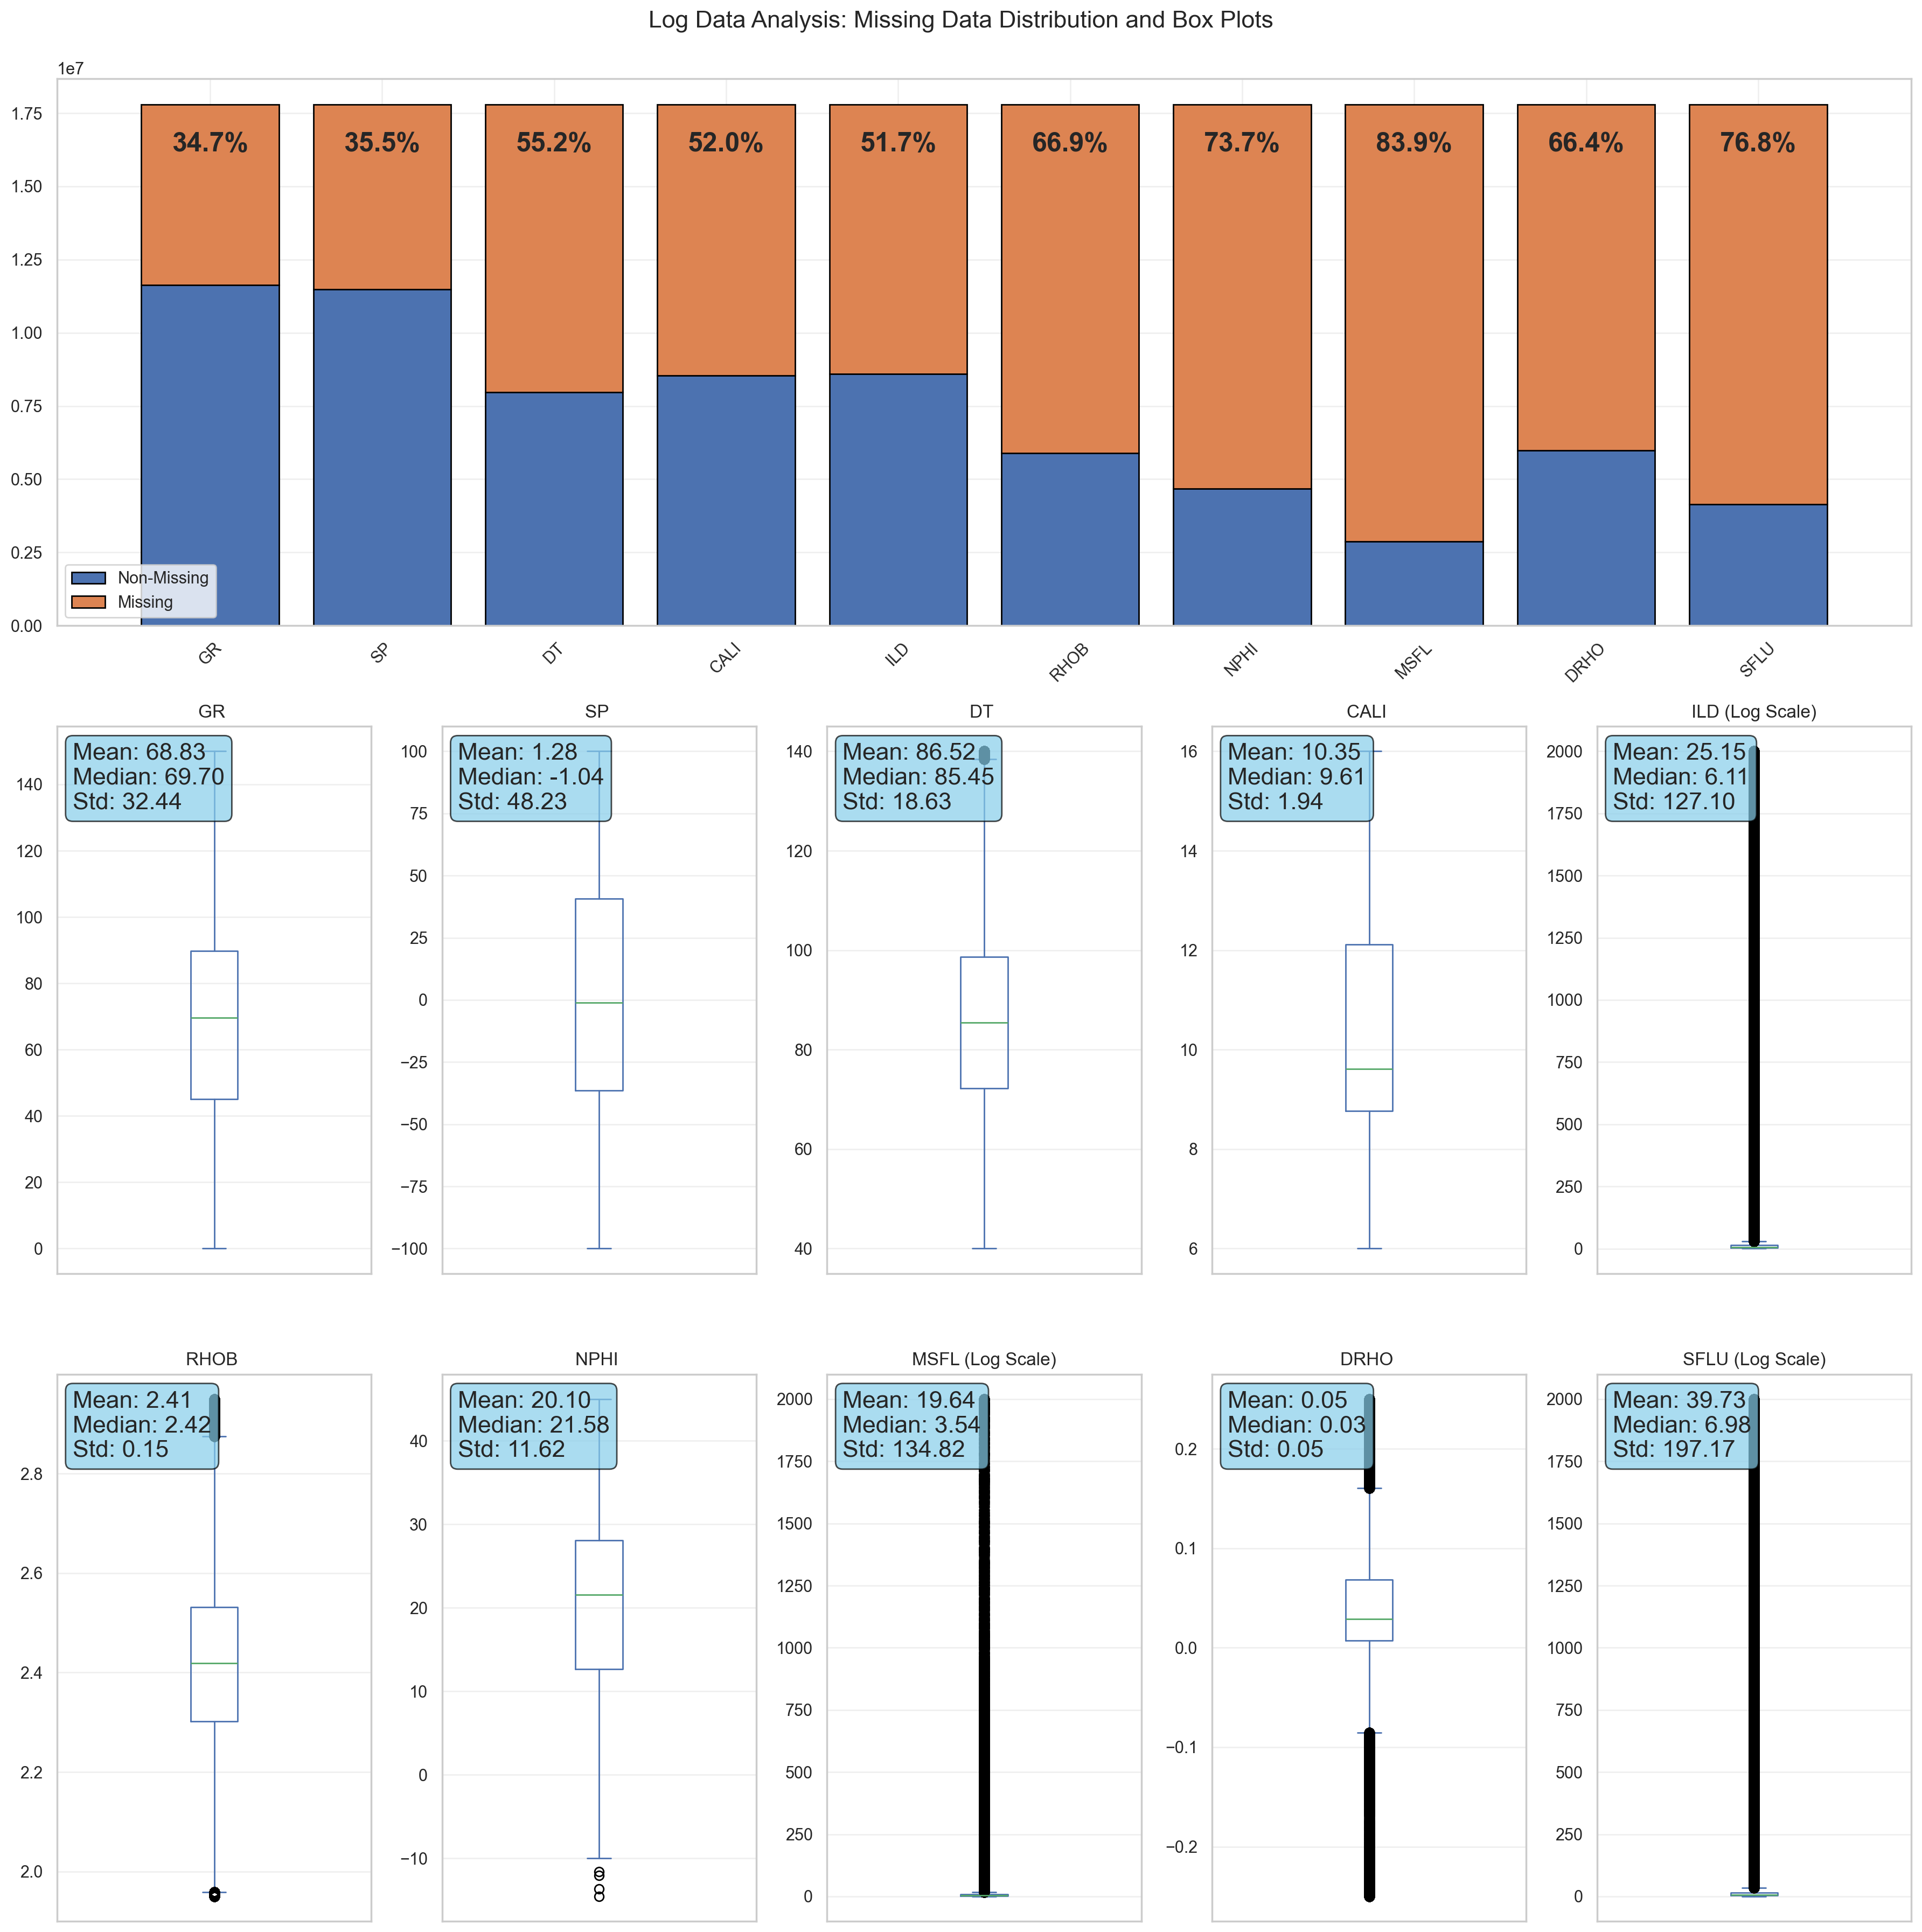

In [243]:
import pandas as pd

########################## MISSING DATA DISTRIBUTION ##########################
# 1. Distribution of missing data by log type
missing_data_analysis = []

for col in features_columns:
    if col in ['depth', 'top']:  # Skip depth and top as they're not log types
        continue
    
    total_rows = len(df_features_filtered)
    missing_count = df_features_filtered[col].isna().sum()
    non_missing_count = total_rows - missing_count
    missing_percentage = (missing_count / total_rows) * 100
    
    missing_data_analysis.append({
        'Log_Type': col,
        'Missing': missing_count,
        'Non_Missing': non_missing_count,
        'Missing_Percentage': missing_percentage
    })

missing_df = pd.DataFrame(missing_data_analysis)

################################ BOX PLOTS ##########################

columns_to_exclude = ['depth', 'top', 'bottom', 'well']
filtered_numeric_columns = [col for col in numeric_columns if col.lower() not in [c.lower() for c in columns_to_exclude]]

# Create box plots for the filtered numeric columns (excluding depth, top, bottom)
filtered_numeric_columns_clean = [col for col in filtered_numeric_columns if col.lower() not in [c.lower() for c in columns_to_exclude]]

# Define log-scale logs (resistivity measurements)
log_scale_logs = {'ILD', 'MSFL', 'SFLU'}

n_cols_clean = len(filtered_numeric_columns_clean)
n_rows_clean = (n_cols_clean + 4) // 5  # 5 columns per row

# Create figure with missing data chart at top and box plots at bottom
#fig, axes = plt.subplots(n_rows_clean + 1, 3, figsize=(18, 6 * (n_rows_clean + 1)))
fig = plt.figure(figsize=(18, 6 * (n_rows_clean + 1)), dpi=200)
fig.suptitle('Log Data Analysis: Missing Data Distribution and Box Plots', fontsize=16, y=0.995)

#fig.suptitle('Log Data Analysis: Missing Data Distribution and Box Plots', fontsize=16, y=1)

# Missing data distribution chart - spans all 3 columns in first row
ax_missing = plt.subplot2grid((n_rows_clean + 1, 5), (0, 0), colspan=5)

log_types = missing_df['Log_Type']
missing_counts = missing_df['Missing']
non_missing_counts = missing_df['Non_Missing']

# Stacked bar chart
ax_missing.bar(log_types, non_missing_counts, label='Non-Missing', edgecolor='black')
ax_missing.bar(log_types, missing_counts, bottom=non_missing_counts, label='Missing', edgecolor='black')

#ax_missing.set_title('Distribution of Missing Data by Log Type', fontsize=14, fontweight='bold')
#ax_missing.set_xlabel('Log Types')
#ax_missing.set_ylabel('Samples')
#ax_missing.set_ybound(0, len(df_features_filtered))
#ax_missing.set_ylim(0, len(df_features_filtered))
ax_missing.legend()
ax_missing.grid(True, alpha=0.3)
ax_missing.tick_params(axis='x', rotation=45)

# Add percentage labels on top of each bar
for i, row in missing_df.iterrows():
    total_height = row['Missing'] + row['Non_Missing']
    ax_missing.text(i, total_height + max(missing_df['Missing'] + missing_df['Non_Missing']) * -0.1, f'{row["Missing_Percentage"]:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=18)

log_scale_logs = {'ILD', 'MSFL', 'SFLU'}

# Box plots - starting from second row
for i, col in enumerate(filtered_numeric_columns_clean):
    row = (i // 5) + 1  # Start from row 1 (second row)
    col_pos = i % 5
    ax = plt.subplot2grid((n_rows_clean + 1, 5), (row, col_pos))
    
    # Prepare data (log10 scale for resistivity logs)
    col_data = df_features_filtered[col].dropna()
    plot_data = col_data
    ylabel = 'Values'
    title_suffix = ''
    if col in log_scale_logs:
        title_suffix = '(Log Scale)'
    
    # Create box plot
    if len(plot_data) > 0:
        plot_data.plot(kind='box', ax=ax, title=f'{col} {title_suffix}',xlabel='')
        ax.set_xlabel('')
        ax.set_xticks([])
    else:
        ax.set_title(f'{col} - No Data')
    
    #ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    
    # Add statistics text (reported in original units)
    if len(col_data) > 0:
        stats_text = f'Mean: {col_data.mean():.2f}\nMedian: {col_data.median():.2f}\nStd: {col_data.std():.2f}'
    else:
        stats_text = 'Mean: nan\nMedian: nan\nStd: nan'
    ax.text(0.05, 0.97, stats_text, transform=ax.transAxes, fontsize=16, 
            verticalalignment='top', bbox=dict(edgecolor='black', boxstyle='round', alpha=0.7, facecolor='skyblue'))

plt.tight_layout()
plt.show()


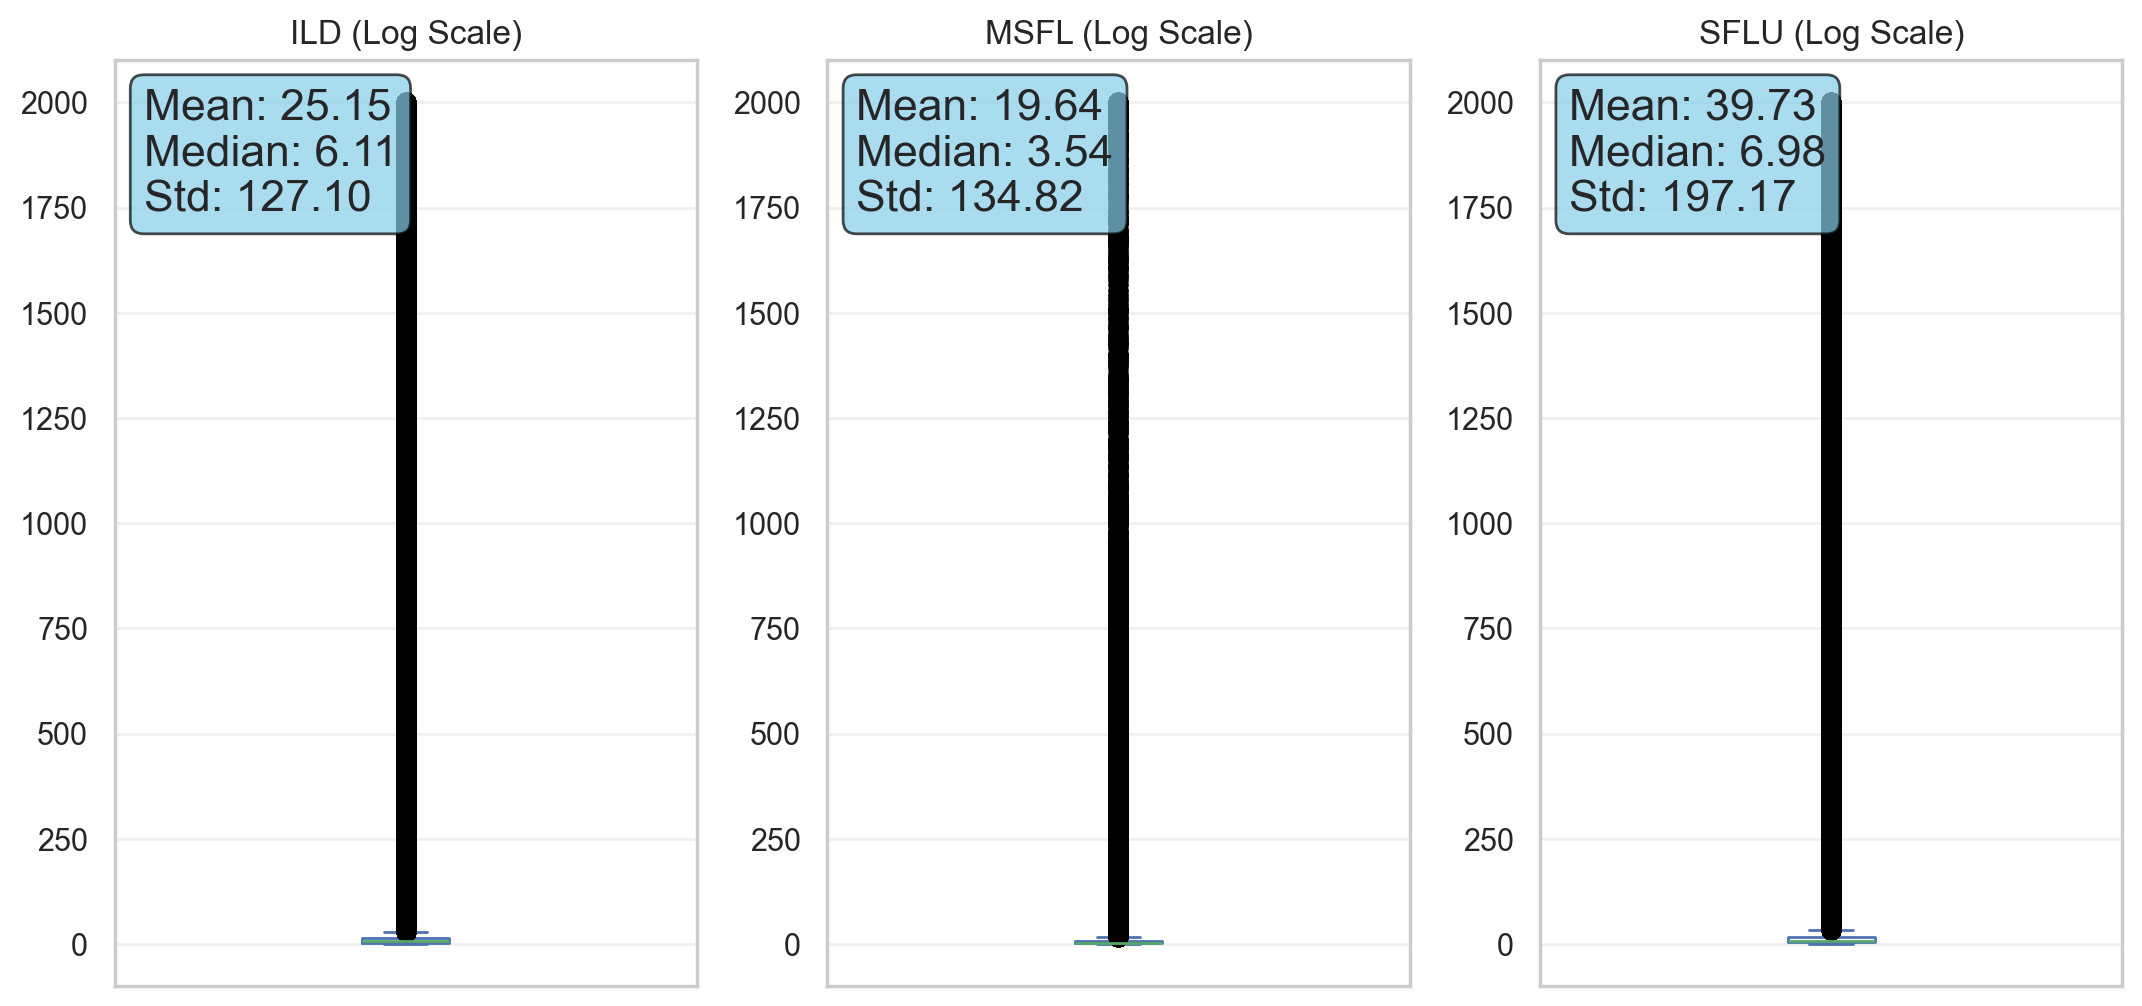

In [255]:
fig = plt.figure(figsize=(18, 10), dpi=200)

columns_to_exclude = ['depth', 'top', 'bottom', 'well', 'NPHI', 'RHOB', 'DT', 'CALI', 'GR', 'SP', 'DRHO'] 
filtered_numeric_columns = [col for col in numeric_columns if col.lower() not in [c.lower() for c in columns_to_exclude]]

# Create box plots for the filtered numeric columns (excluding depth, top, bottom)
filtered_numeric_columns_clean = [col for col in filtered_numeric_columns if col.lower() not in [c.lower() for c in columns_to_exclude]]

# Box plots - starting from second row
for i, col in enumerate(filtered_numeric_columns_clean):
    row = (i // 5)  # Start from row 1 (second row)
    col_pos = i % 5
    ax = plt.subplot2grid((n_rows_clean, 5), (row, col_pos))
    
    # Prepare data (log10 scale for resistivity logs)
    col_data = df_features_filtered[col].dropna()
    plot_data = col_data
    ylabel = 'Values'
    title_suffix = ''
    if col in log_scale_logs:
        title_suffix = '(Log Scale)'
    
    # Create box plot
    if len(plot_data) > 0:
        plot_data.plot(kind='box', ax=ax, title=f'{col} {title_suffix}',xlabel='')
        ax.set_xlabel('')
        ax.set_xticks([])
    else:
        ax.set_title(f'{col} - No Data')
    
    #ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    
    # Add statistics text (reported in original units)
    if len(col_data) > 0:
        stats_text = f'Mean: {col_data.mean():.2f}\nMedian: {col_data.median():.2f}\nStd: {col_data.std():.2f}'
    else:
        stats_text = 'Mean: nan\nMedian: nan\nStd: nan'
    ax.text(0.05, 0.97, stats_text, transform=ax.transAxes, fontsize=16, 
            verticalalignment='top', bbox=dict(edgecolor='black', boxstyle='round', alpha=0.7, facecolor='skyblue'))

plt.tight_layout()
plt.show()

In [ ]:
fig = plt.figure(figsize=(18, 10), dpi=200)

columns_to_exclude = ['depth', 'top', 'bottom', 'well', 'NPHI', 'RHOB', 'DT', 'CALI', 'GR', 'SP', 'DRHO'] 
filtered_numeric_columns = [col for col in numeric_columns if col.lower() not in [c.lower() for c in columns_to_exclude]]

# Create box plots for the filtered numeric columns (excluding depth, top, bottom)
filtered_numeric_columns_clean = [col for col in filtered_numeric_columns if col.lower() not in [c.lower() for c in columns_to_exclude]]

# Box plots - starting from second row
for i, col in enumerate(filtered_numeric_columns_clean):
    row = (i // 5)  # Start from row 1 (second row)
    col_pos = i % 5
    ax = plt.subplot2grid((n_rows_clean, 5), (row, col_pos))
    
    # Prepare data (log10 scale for resistivity logs)
    col_data = df_features_filtered[col].dropna()
    plot_data = col_data
    ylabel = 'Values'
    title_suffix = ''
    if col in log_scale_logs:
        title_suffix = '(Log Scale)'
    
    # Create box plot
    if len(plot_data) > 0:
        plot_data.plot(kind='box', ax=ax, title=f'{col} {title_suffix}',xlabel='')
        ax.set_xlabel('')
        ax.set_xticks([])
    else:
        ax.set_title(f'{col} - No Data')
    
    #ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    
    # Add statistics text (reported in original units)
    if len(col_data) > 0:
        stats_text = f'Mean: {col_data.mean():.2f}\nMedian: {col_data.median():.2f}\nStd: {col_data.std():.2f}'
    else:
        stats_text = 'Mean: nan\nMedian: nan\nStd: nan'
    ax.text(0.05, 0.97, stats_text, transform=ax.transAxes, fontsize=16, 
            verticalalignment='top', bbox=dict(edgecolor='black', boxstyle='round', alpha=0.7, facecolor='skyblue'))

plt.tight_layout()
plt.show()

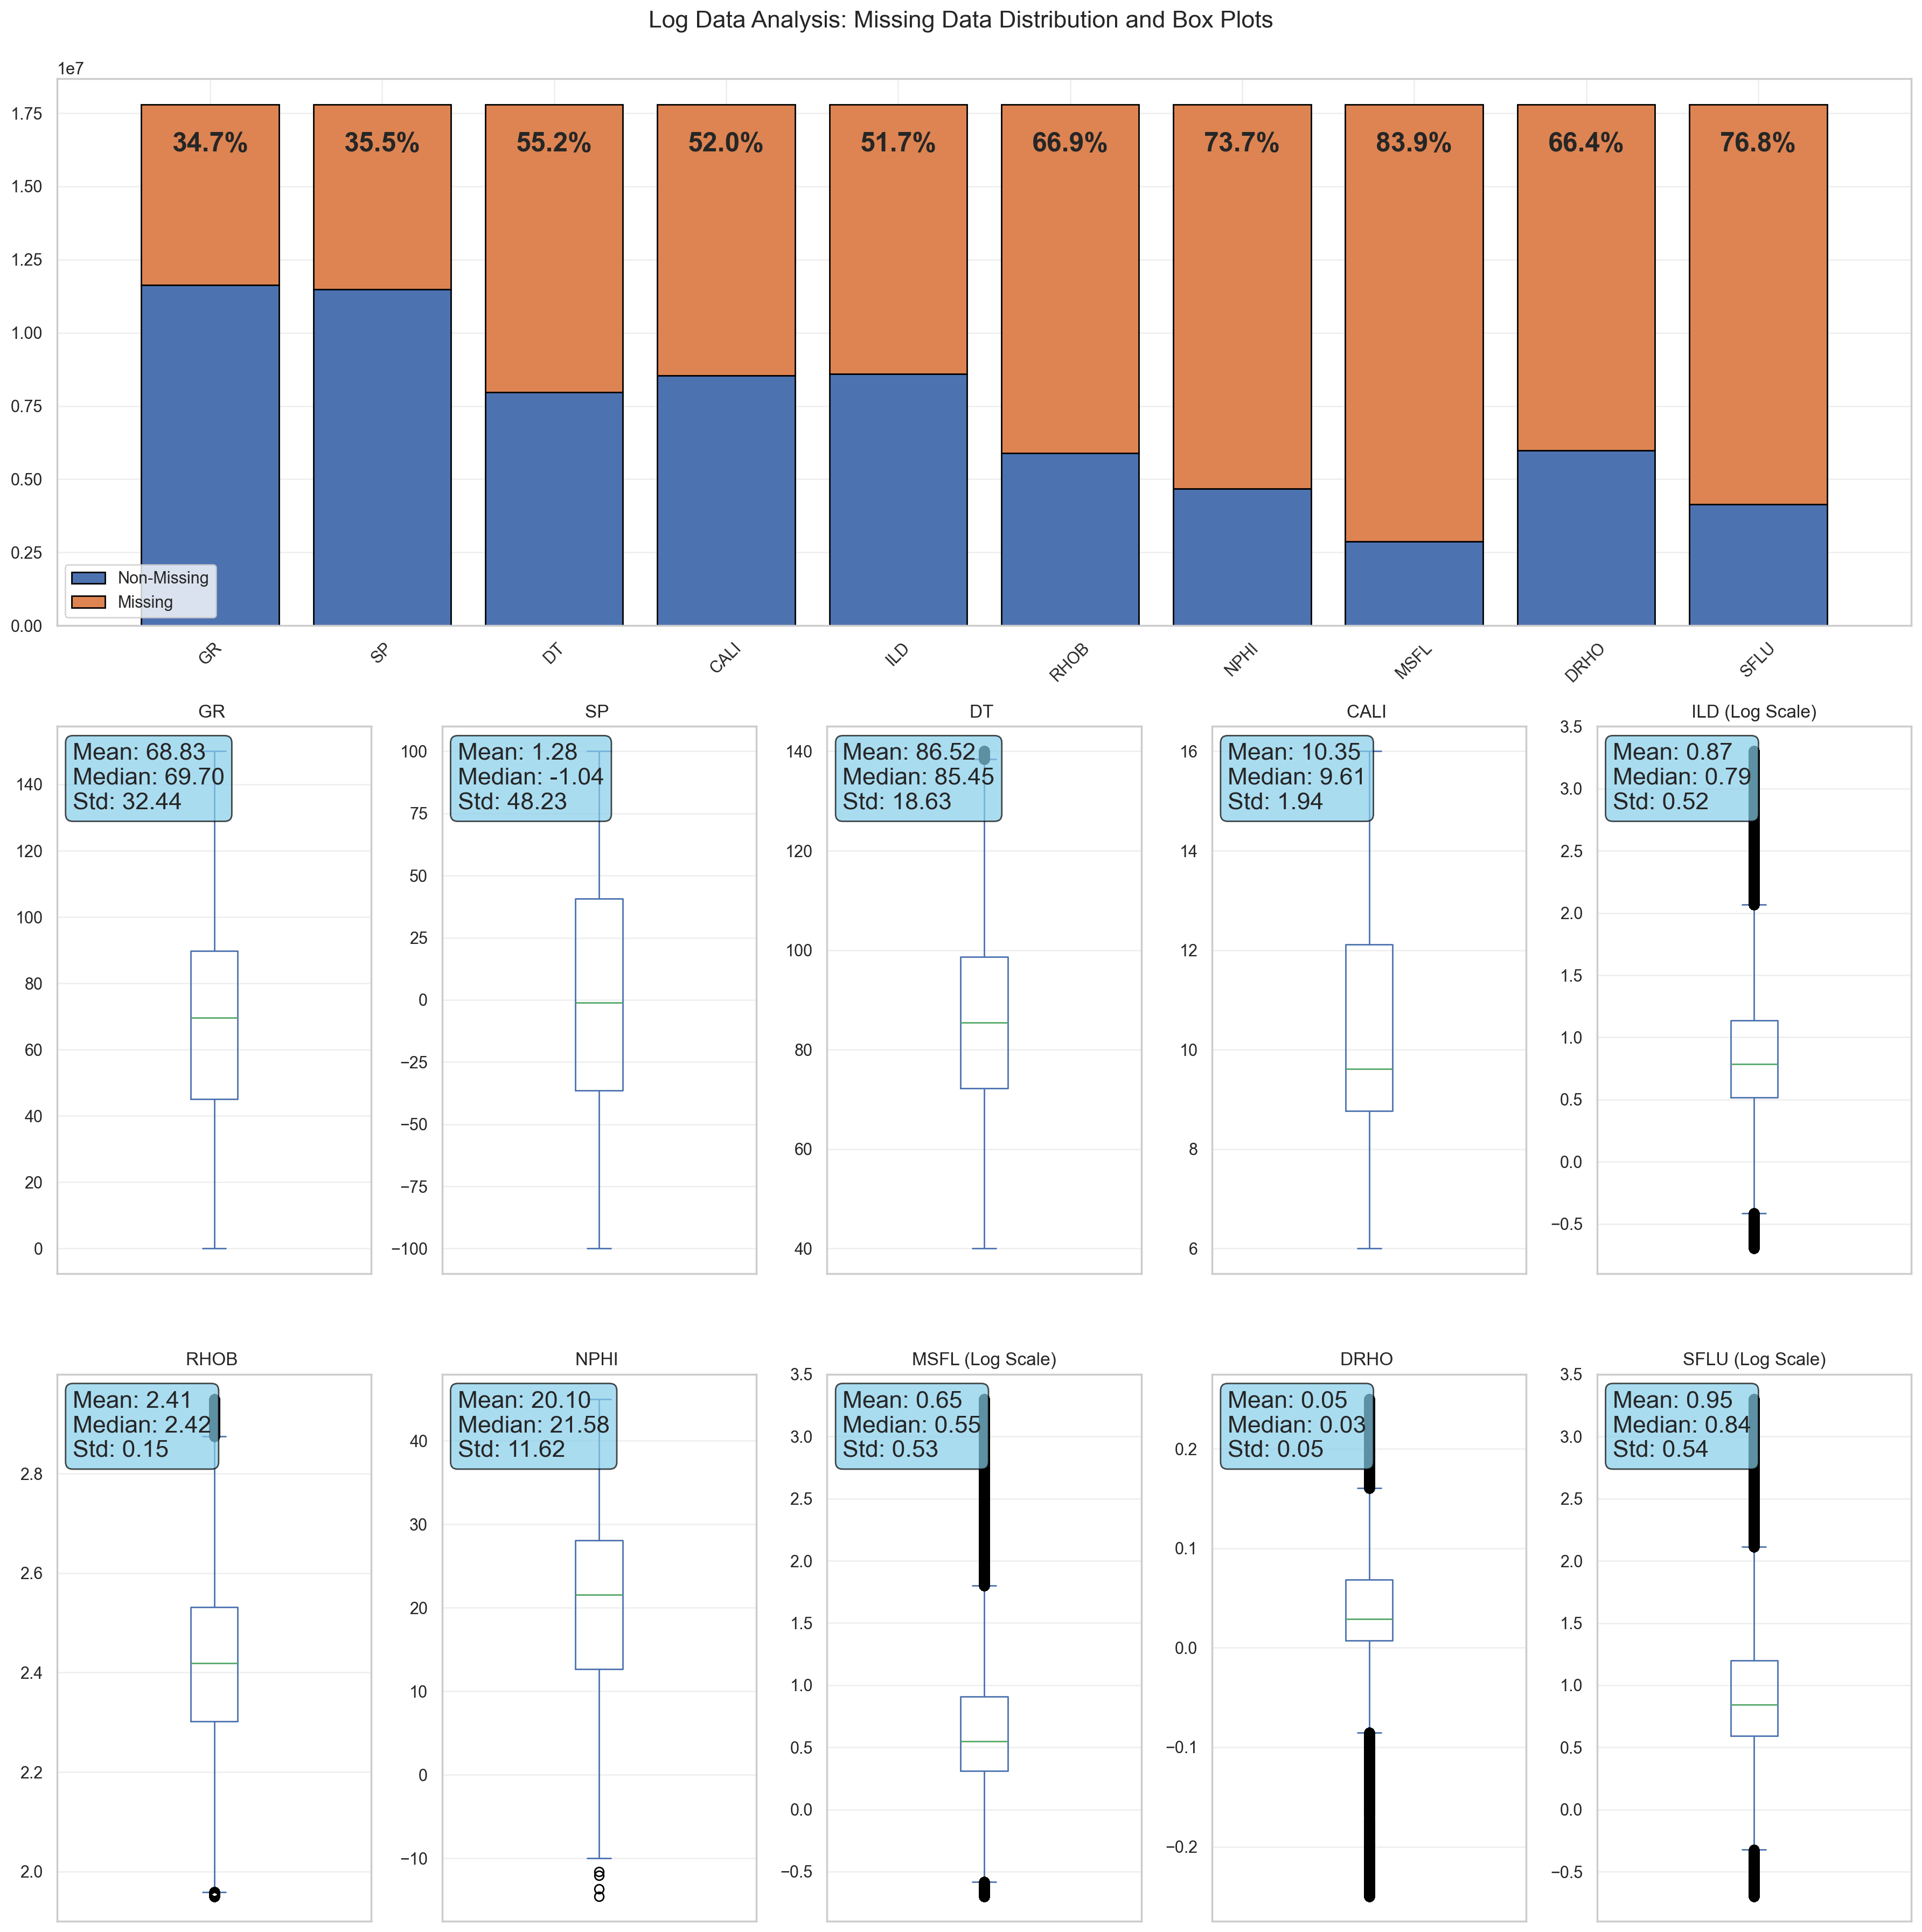

In [238]:
import pandas as pd

########################## MISSING DATA DISTRIBUTION ##########################
# 1. Distribution of missing data by log type
missing_data_analysis = []

for col in features_columns:
    if col in ['depth', 'top']:  # Skip depth and top as they're not log types
        continue
    
    total_rows = len(df_features_filtered)
    missing_count = df_features_filtered[col].isna().sum()
    non_missing_count = total_rows - missing_count
    missing_percentage = (missing_count / total_rows) * 100
    
    missing_data_analysis.append({
        'Log_Type': col,
        'Missing': missing_count,
        'Non_Missing': non_missing_count,
        'Missing_Percentage': missing_percentage
    })

missing_df = pd.DataFrame(missing_data_analysis)

################################ BOX PLOTS ##########################

columns_to_exclude = ['depth', 'top', 'bottom', 'well']
filtered_numeric_columns = [col for col in numeric_columns if col.lower() not in [c.lower() for c in columns_to_exclude]]

# Create box plots for the filtered numeric columns (excluding depth, top, bottom)
filtered_numeric_columns_clean = [col for col in filtered_numeric_columns if col.lower() not in [c.lower() for c in columns_to_exclude]]

# Define log-scale logs (resistivity measurements)
log_scale_logs = {'ILD', 'MSFL', 'SFLU'}

n_cols_clean = len(filtered_numeric_columns_clean)
n_rows_clean = (n_cols_clean + 4) // 5  # 5 columns per row

# Create figure with missing data chart at top and box plots at bottom
#fig, axes = plt.subplots(n_rows_clean + 1, 3, figsize=(18, 6 * (n_rows_clean + 1)))
fig = plt.figure(figsize=(18, 6 * (n_rows_clean + 1)), dpi=200)
fig.suptitle('Log Data Analysis: Missing Data Distribution and Box Plots', fontsize=16, y=0.995)

#fig.suptitle('Log Data Analysis: Missing Data Distribution and Box Plots', fontsize=16, y=1)

# Missing data distribution chart - spans all 3 columns in first row
ax_missing = plt.subplot2grid((n_rows_clean + 1, 5), (0, 0), colspan=5)

log_types = missing_df['Log_Type']
missing_counts = missing_df['Missing']
non_missing_counts = missing_df['Non_Missing']

# Stacked bar chart
ax_missing.bar(log_types, non_missing_counts, label='Non-Missing', edgecolor='black')
ax_missing.bar(log_types, missing_counts, bottom=non_missing_counts, label='Missing', edgecolor='black')

#ax_missing.set_title('Distribution of Missing Data by Log Type', fontsize=14, fontweight='bold')
#ax_missing.set_xlabel('Log Types')
#ax_missing.set_ylabel('Samples')
#ax_missing.set_ybound(0, len(df_features_filtered))
#ax_missing.set_ylim(0, len(df_features_filtered))
ax_missing.legend()
ax_missing.grid(True, alpha=0.3)
ax_missing.tick_params(axis='x', rotation=45)

# Add percentage labels on top of each bar
for i, row in missing_df.iterrows():
    total_height = row['Missing'] + row['Non_Missing']
    ax_missing.text(i, total_height + max(missing_df['Missing'] + missing_df['Non_Missing']) * -0.1, f'{row["Missing_Percentage"]:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=18)

log_scale_logs = {'ILD', 'MSFL', 'SFLU'}

# Box plots - starting from second row
for i, col in enumerate(filtered_numeric_columns_clean):
    row = (i // 5) + 1  # Start from row 1 (second row)
    col_pos = i % 5
    ax = plt.subplot2grid((n_rows_clean + 1, 5), (row, col_pos))
    
    # Prepare data (log10 scale for resistivity logs)
    col_data = df_features_filtered[col].dropna()
    plot_data = col_data
    ylabel = 'Values'
    title_suffix = ''
    if col in log_scale_logs:
        title_suffix = '(Log Scale)'
    
    # Create box plot
    if len(plot_data) > 0:
        plot_data.plot(kind='box', ax=ax, title=f'{col} {title_suffix}',xlabel='')
        ax.set_xlabel('')
        ax.set_xticks([])
    else:
        ax.set_title(f'{col} - No Data')
    
    #ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    
    # Add statistics text (reported in original units)
    if len(col_data) > 0:
        stats_text = f'Mean: {col_data.mean():.2f}\nMedian: {col_data.median():.2f}\nStd: {col_data.std():.2f}'
    else:
        stats_text = 'Mean: nan\nMedian: nan\nStd: nan'
    ax.text(0.05, 0.97, stats_text, transform=ax.transAxes, fontsize=16,
            verticalalignment='top', bbox=dict(edgecolor='black', boxstyle='round', alpha=0.7, facecolor='skyblue'))

plt.tight_layout()
plt.show()


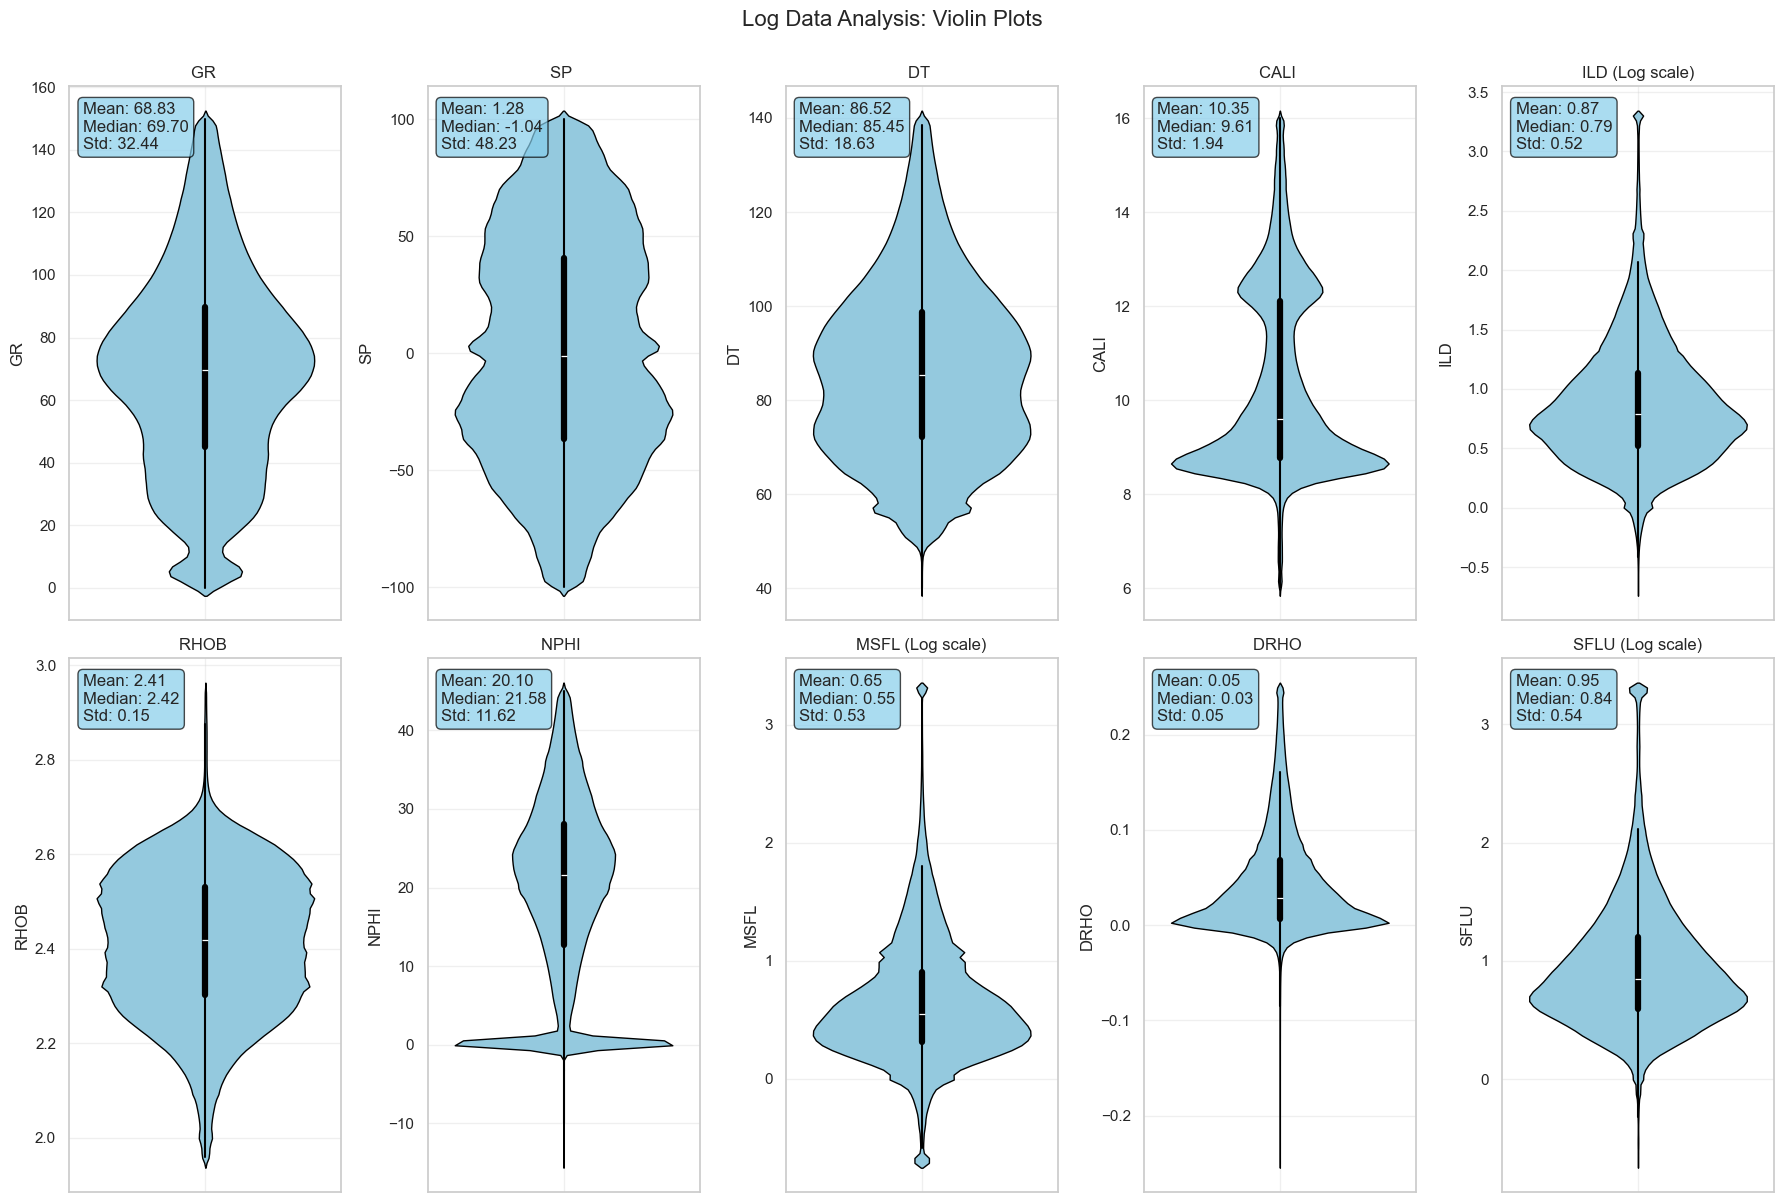

In [112]:
########################## VIOLIN PLOTS (SEPARATE CELL) ##########################
import seaborn as sns
import pandas as pd

columns_to_exclude = ['depth', 'top', 'bottom', 'well']
filtered_numeric_columns_clean = [
    col for col in numeric_columns
    if col.lower() not in [c.lower() for c in columns_to_exclude]
 ]
log_scale_logs = {'ILD', 'MSFL', 'SFLU'}

n_cols_clean = len(filtered_numeric_columns_clean)
n_rows_clean = (n_cols_clean + 4) // 5  # 3 columns per row

fig, axes = plt.subplots(n_rows_clean, 5, figsize=(18, 6 * n_rows_clean))
fig.suptitle('Log Data Analysis: Violin Plots', fontsize=16, y=1)

if n_rows_clean == 1:
    axes = np.array([axes])

for i, col in enumerate(filtered_numeric_columns_clean):
    row = i // 5
    col_pos = i % 5
    ax = axes[row, col_pos]
    
    # Prepare data (log10 scale for resistivity logs)
    col_data = df_features_filtered[col].dropna()
    plot_data = col_data
    plot_label = 'Values'
    title_suffix = ''

    if col in log_scale_logs:
        col_data_positive = col_data[col_data > 0]
        if len(col_data_positive) > 0:
            title_suffix = '(Log scale)'
        else:
            plot_data = pd.Series(dtype=float)

    # Create violin plot
    if len(plot_data) > 0:
        sns.violinplot(y=plot_data, ax=ax, inner='box', linewidth=1, color='skyblue', edgecolor='black')
        ax.set_title(f'{col} {title_suffix}')
    else:
        ax.text(0.5, 0.5, f'No valid data available for {col}', transform=ax.transAxes, ha='center', va='center')
        ax.set_title(f'{col} - No Data')

    #ax.set_ylabel(plot_label)
    ax.grid(True, alpha=0.3)
    
    # Add statistics text (reported in original units)
    if len(col_data) > 0:
        stats_text = f'Mean: {col_data.mean():.2f}\nMedian: {col_data.median():.2f}\nStd: {col_data.std():.2f}'
    else:
        stats_text = 'Mean: nan\nMedian: nan\nStd: nan'
    ax.text(0.05, 0.97, stats_text, transform=ax.transAxes,
            verticalalignment='top', bbox=dict(edgecolor='black', boxstyle='round', alpha=0.7, facecolor='skyblue'))

# Hide unused subplots
for i in range(len(filtered_numeric_columns_clean), n_rows_clean * 5):
    row = i // 5
    col_pos = i % 5
    axes[row, col_pos].set_visible(False)

plt.tight_layout()
plt.show()

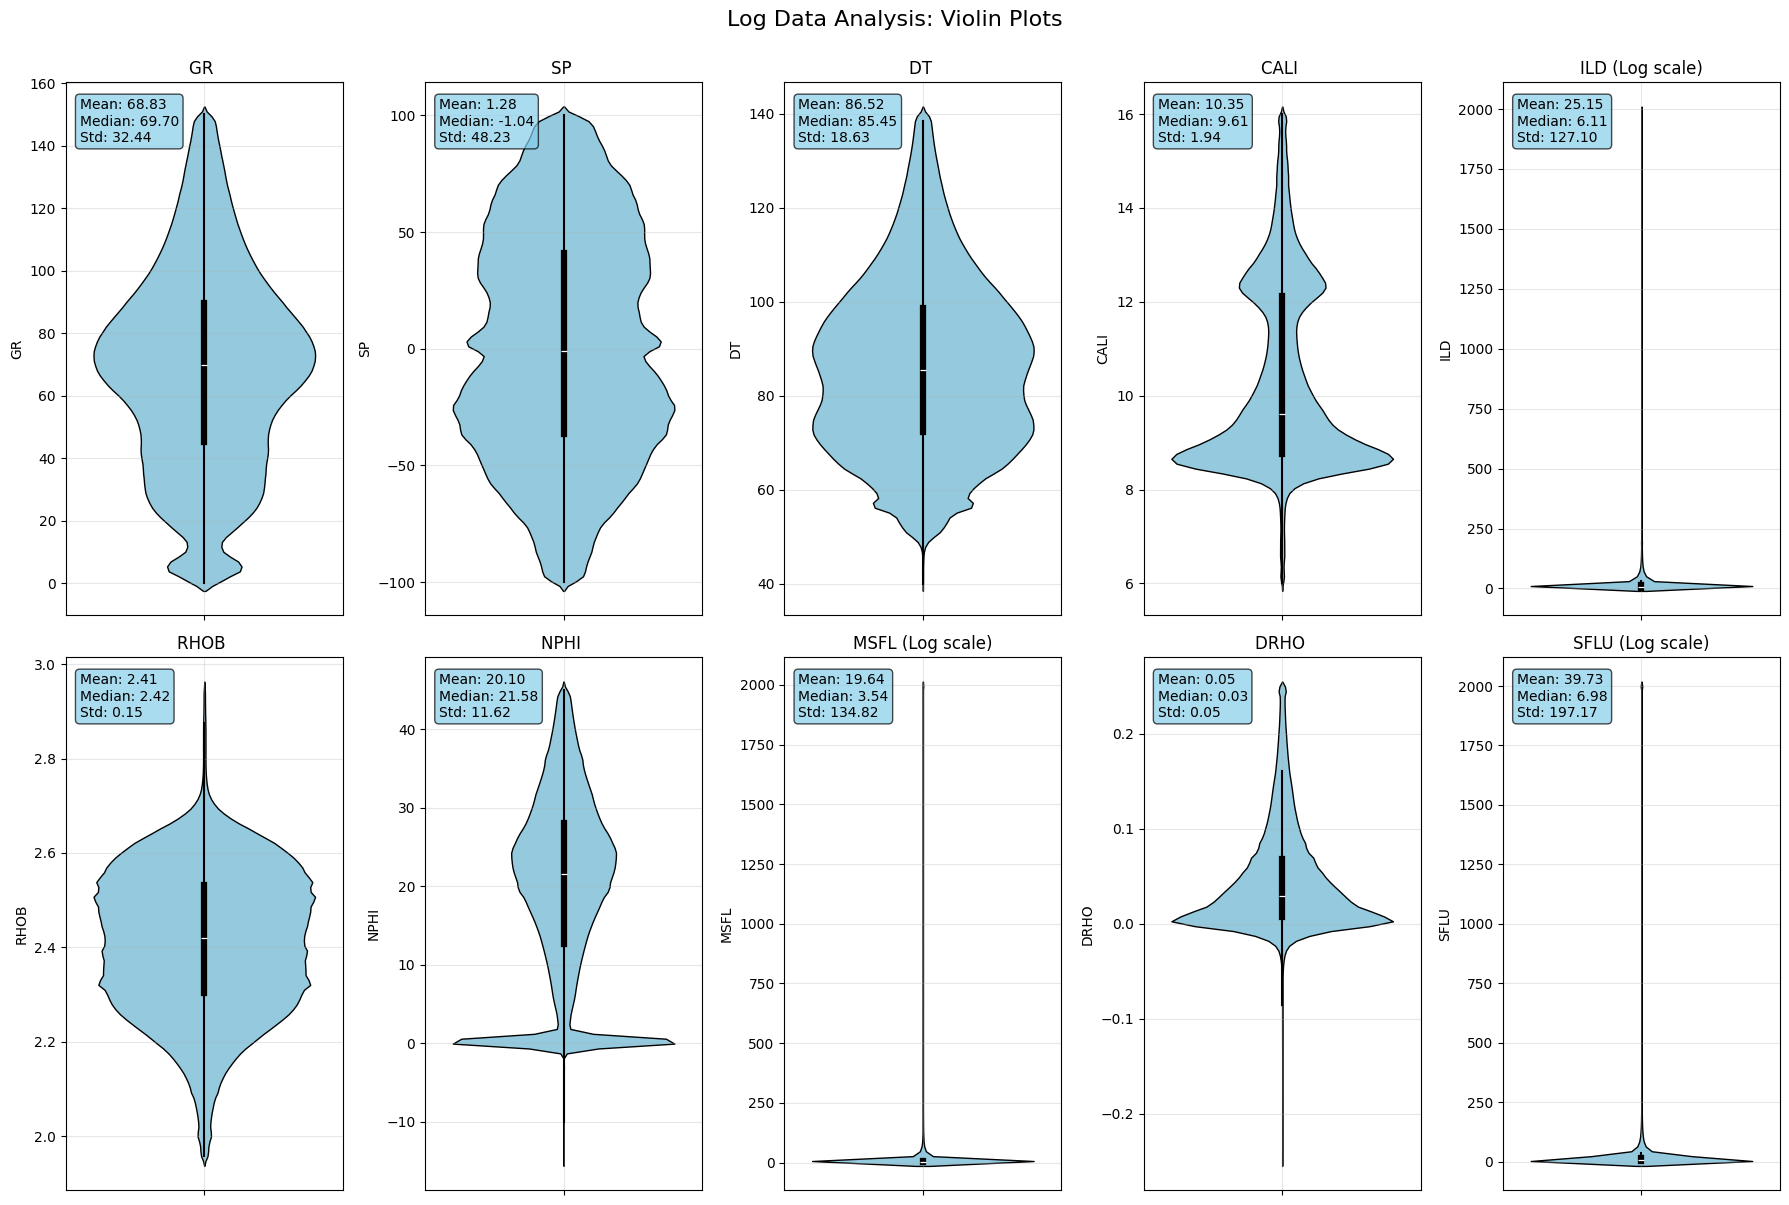

In [188]:
########################## VIOLIN PLOTS (SEPARATE CELL) ##########################
import seaborn as sns
import pandas as pd

columns_to_exclude = ['depth', 'top', 'bottom', 'well']
filtered_numeric_columns_clean = [
    col for col in numeric_columns
    if col.lower() not in [c.lower() for c in columns_to_exclude]
 ]
log_scale_logs = {'ILD', 'MSFL', 'SFLU'}

n_cols_clean = len(filtered_numeric_columns_clean)
n_rows_clean = (n_cols_clean + 4) // 5  # 3 columns per row

fig, axes = plt.subplots(n_rows_clean, 5, figsize=(18, 6 * n_rows_clean))
fig.suptitle('Log Data Analysis: Violin Plots', fontsize=16, y=1)

if n_rows_clean == 1:
    axes = np.array([axes])

for i, col in enumerate(filtered_numeric_columns_clean):
    row = i // 5
    col_pos = i % 5
    ax = axes[row, col_pos]
    
    # Prepare data (log10 scale for resistivity logs)
    col_data = df_features_filtered[col].dropna()
    plot_data = col_data
    plot_label = 'Values'
    title_suffix = ''

    if col in log_scale_logs:
        col_data_positive = col_data[col_data > 0]
        if len(col_data_positive) > 0:
            title_suffix = '(Log scale)'
        else:
            plot_data = pd.Series(dtype=float)

    # Create violin plot
    if len(plot_data) > 0:
        sns.violinplot(y=plot_data, ax=ax, inner='box', linewidth=1, color='skyblue', edgecolor='black')
        ax.set_title(f'{col} {title_suffix}')
    else:
        ax.text(0.5, 0.5, f'No valid data available for {col}', transform=ax.transAxes, ha='center', va='center')
        ax.set_title(f'{col} - No Data')

    #ax.set_ylabel(plot_label)
    ax.grid(True, alpha=0.3)
    
    # Add statistics text (reported in original units)
    if len(col_data) > 0:
        stats_text = f'Mean: {col_data.mean():.2f}\nMedian: {col_data.median():.2f}\nStd: {col_data.std():.2f}'
    else:
        stats_text = 'Mean: nan\nMedian: nan\nStd: nan'
    ax.text(0.05, 0.97, stats_text, transform=ax.transAxes,
            verticalalignment='top', bbox=dict(edgecolor='black', boxstyle='round', alpha=0.7, facecolor='skyblue'))

# Hide unused subplots
for i in range(len(filtered_numeric_columns_clean), n_rows_clean * 5):
    row = i // 5
    col_pos = i % 5
    axes[row, col_pos].set_visible(False)

plt.tight_layout()
plt.show()

In [102]:
######################### Missing Data Summary ##################

print("\nMissing Data Summary:")
print("=" * 40)
for _, row in missing_df.iterrows():
    print(f"{row['Log_Type']}: {row['Missing_Percentage']:.1f}% missing ({row['Missing']:,} out of {row['Missing'] + row['Non_Missing']:,})")



Missing Data Summary:
GR: 34.7% missing (6,168,147 out of 17,791,219)
SP: 35.5% missing (6,309,038 out of 17,791,219)
DT: 55.2% missing (9,826,375 out of 17,791,219)
CALI: 52.0% missing (9,245,179 out of 17,791,219)
ILD: 51.7% missing (9,193,000 out of 17,791,219)
RHOB: 66.9% missing (11,908,932 out of 17,791,219)
NPHI: 73.7% missing (13,119,418 out of 17,791,219)
MSFL: 83.9% missing (14,921,455 out of 17,791,219)
DRHO: 66.4% missing (11,816,731 out of 17,791,219)
SFLU: 76.8% missing (13,656,377 out of 17,791,219)


### Plot Log Bell Curves

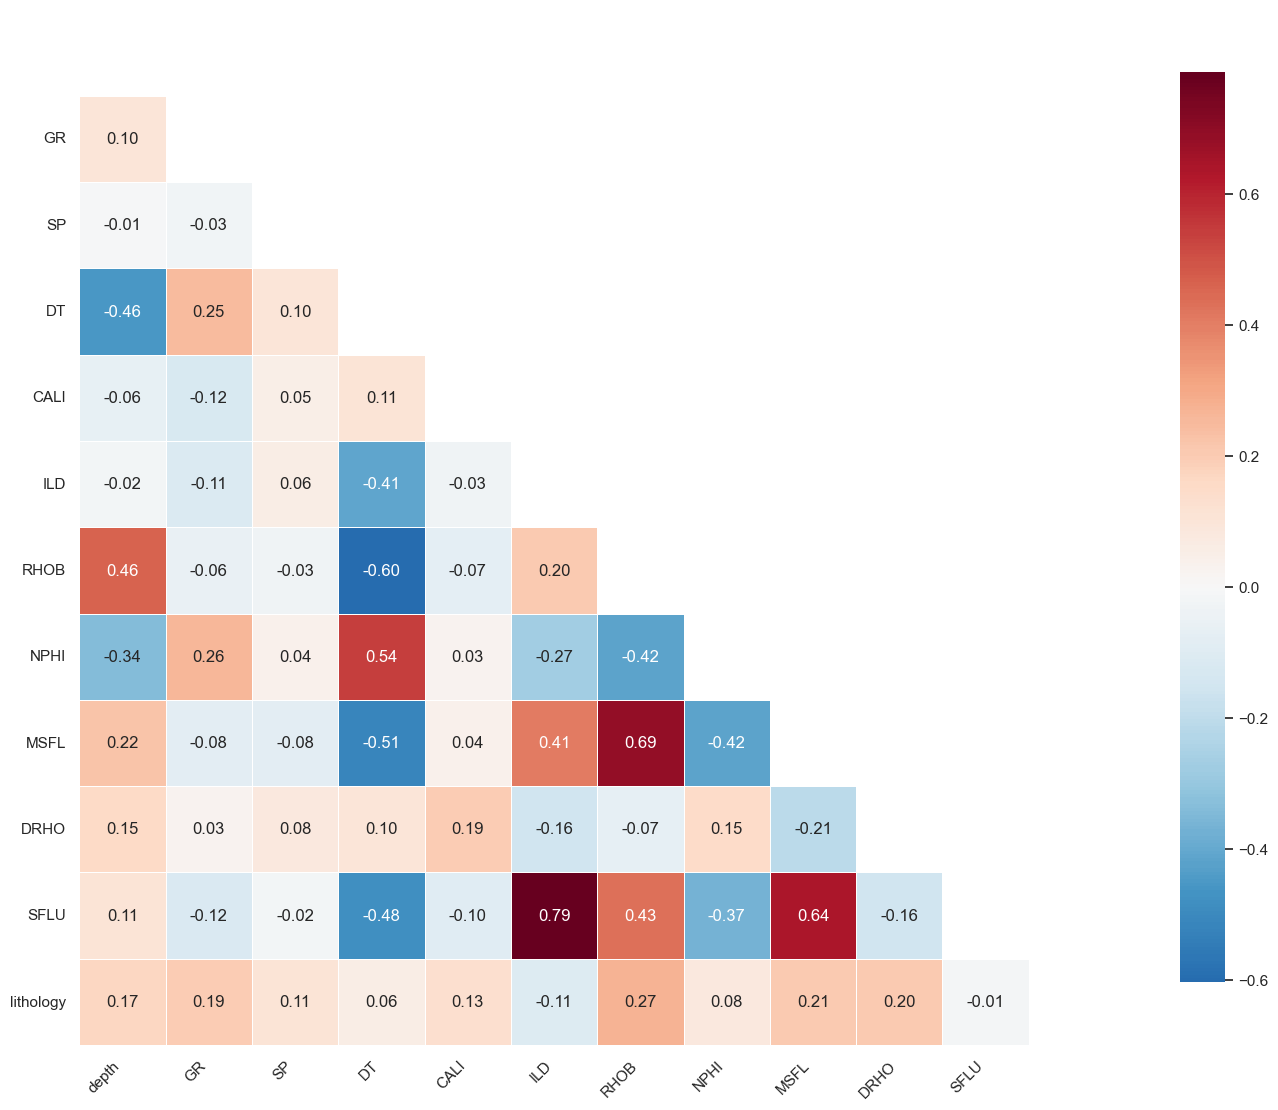

In [157]:
import seaborn as sns
from scipy import stats

# Create histograms (bell curves) to check for normal distribution
import matplotlib.pyplot as plt
sns.set_theme(context='notebook', style='whitegrid', palette='deep', font='sans-serif', font_scale=1, color_codes=True, rc=None)
########################## CORRELATION MATRIX ##########################

# Create correlation matrix for numeric columns in the filtered dataset
columns = df_features_filtered.columns.copy()
columns = columns.drop(["well","basin"])
df_features_cleaned = df_features_filtered.copy()
df_features_cleaned[target_column] = df_features_filtered[target_column].astype('category').cat.codes
correlation_matrix = df_features_cleaned[columns].corr()

# Create heatmap using matplotlib and seaborn
plt.figure(figsize=(14, 12))

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=0)
ax = sns.heatmap(correlation_matrix, 
            mask=mask,
            annot=True, 
            cmap='RdBu_r', 
            center=0,
            square=True,
            fmt='.2f',
            cbar_kws={'shrink': 0.8},
            linewidths=0.5)

# Keep k=0 mask and trim labels as requested
labels = correlation_matrix.columns.tolist()
ax.set_xticks(np.arange(0, len(labels) - 1) + 0.5)
ax.set_xticklabels(labels[:-1], rotation=45, ha='right')
ax.set_yticks(np.arange(1, len(labels)) + 0.5)
ax.set_yticklabels(labels[1:], rotation=0)

# Adjust colorbar position (y-position and height)
#cbar = ax.collections[0].colorbar
#cbar_ax = cbar.ax
#x, y, w, h = cbar_ax.get_position().bounds
#cbar_y = 0.05
#cbar_h = 0.76
#cbar_ax.set_position([x, cbar_y, w, cbar_h])

plt.grid(False)
#plt.title('Correlation Matrix of Well Log Features (Filtered Data)', fontsize=16, pad=20)
plt.tight_layout()
plt.show()


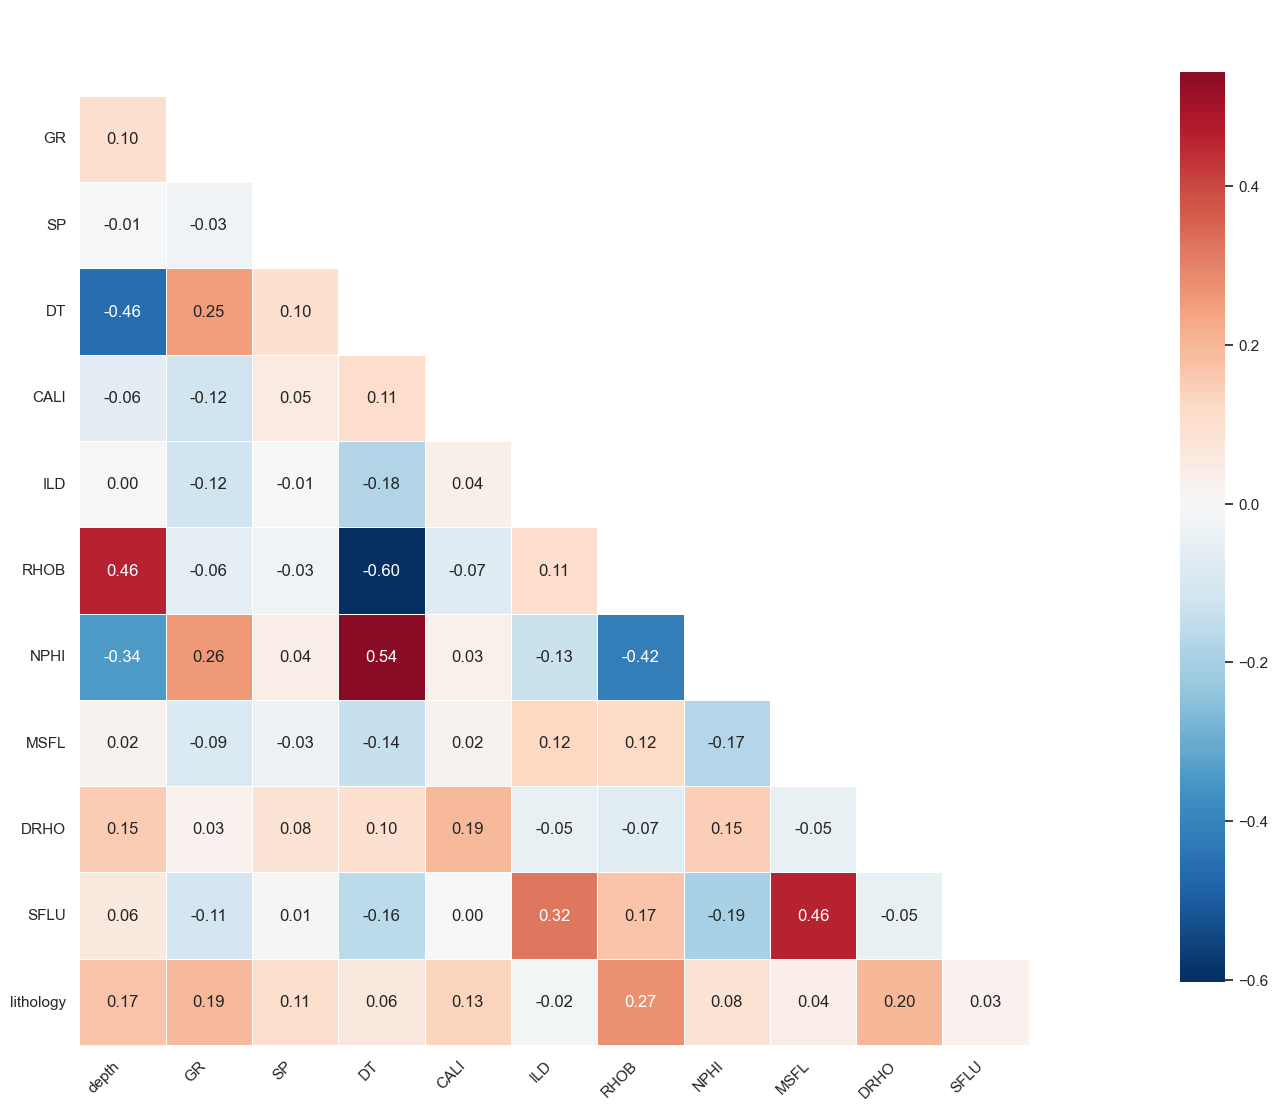

In [160]:
import seaborn as sns
from scipy import stats

# Create histograms (bell curves) to check for normal distribution
import matplotlib.pyplot as plt
sns.set_theme(context='notebook', style='whitegrid', palette='deep', font='sans-serif', font_scale=1, color_codes=True, rc=None)
########################## CORRELATION MATRIX ##########################

# Create correlation matrix for numeric columns in the filtered dataset
columns = df_features_filtered.columns.copy()
columns = columns.drop(["well","basin"])
df_features_cleaned = df_features_filtered.copy()
df_features_cleaned[target_column] = df_features_filtered[target_column].astype('category').cat.codes
correlation_matrix = df_features_cleaned[columns].corr()

# Create heatmap using matplotlib and seaborn
plt.figure(figsize=(14, 12))

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=0)
ax = sns.heatmap(correlation_matrix, 
            mask=mask,
            annot=True, 
            cmap='RdBu_r', 
            center=0,
            square=True,
            fmt='.2f',
            cbar_kws={'shrink': 0.8},
            linewidths=0.5)

# Keep k=0 mask and trim labels as requested
labels = correlation_matrix.columns.tolist()
ax.set_xticks(np.arange(0, len(labels) - 1) + 0.5)
ax.set_xticklabels(labels[:-1], rotation=45, ha='right')
ax.set_yticks(np.arange(1, len(labels)) + 0.5)
ax.set_yticklabels(labels[1:], rotation=0)

# Adjust colorbar position (y-position and height)
#cbar = ax.collections[0].colorbar
#cbar_ax = cbar.ax
#x, y, w, h = cbar_ax.get_position().bounds
#cbar_y = 0.05
#cbar_h = 0.76
#cbar_ax.set_position([x, cbar_y, w, cbar_h])

plt.grid(False)
#plt.title('Correlation Matrix of Well Log Features (Filtered Data)', fontsize=16, pad=20)
plt.tight_layout()
plt.show()


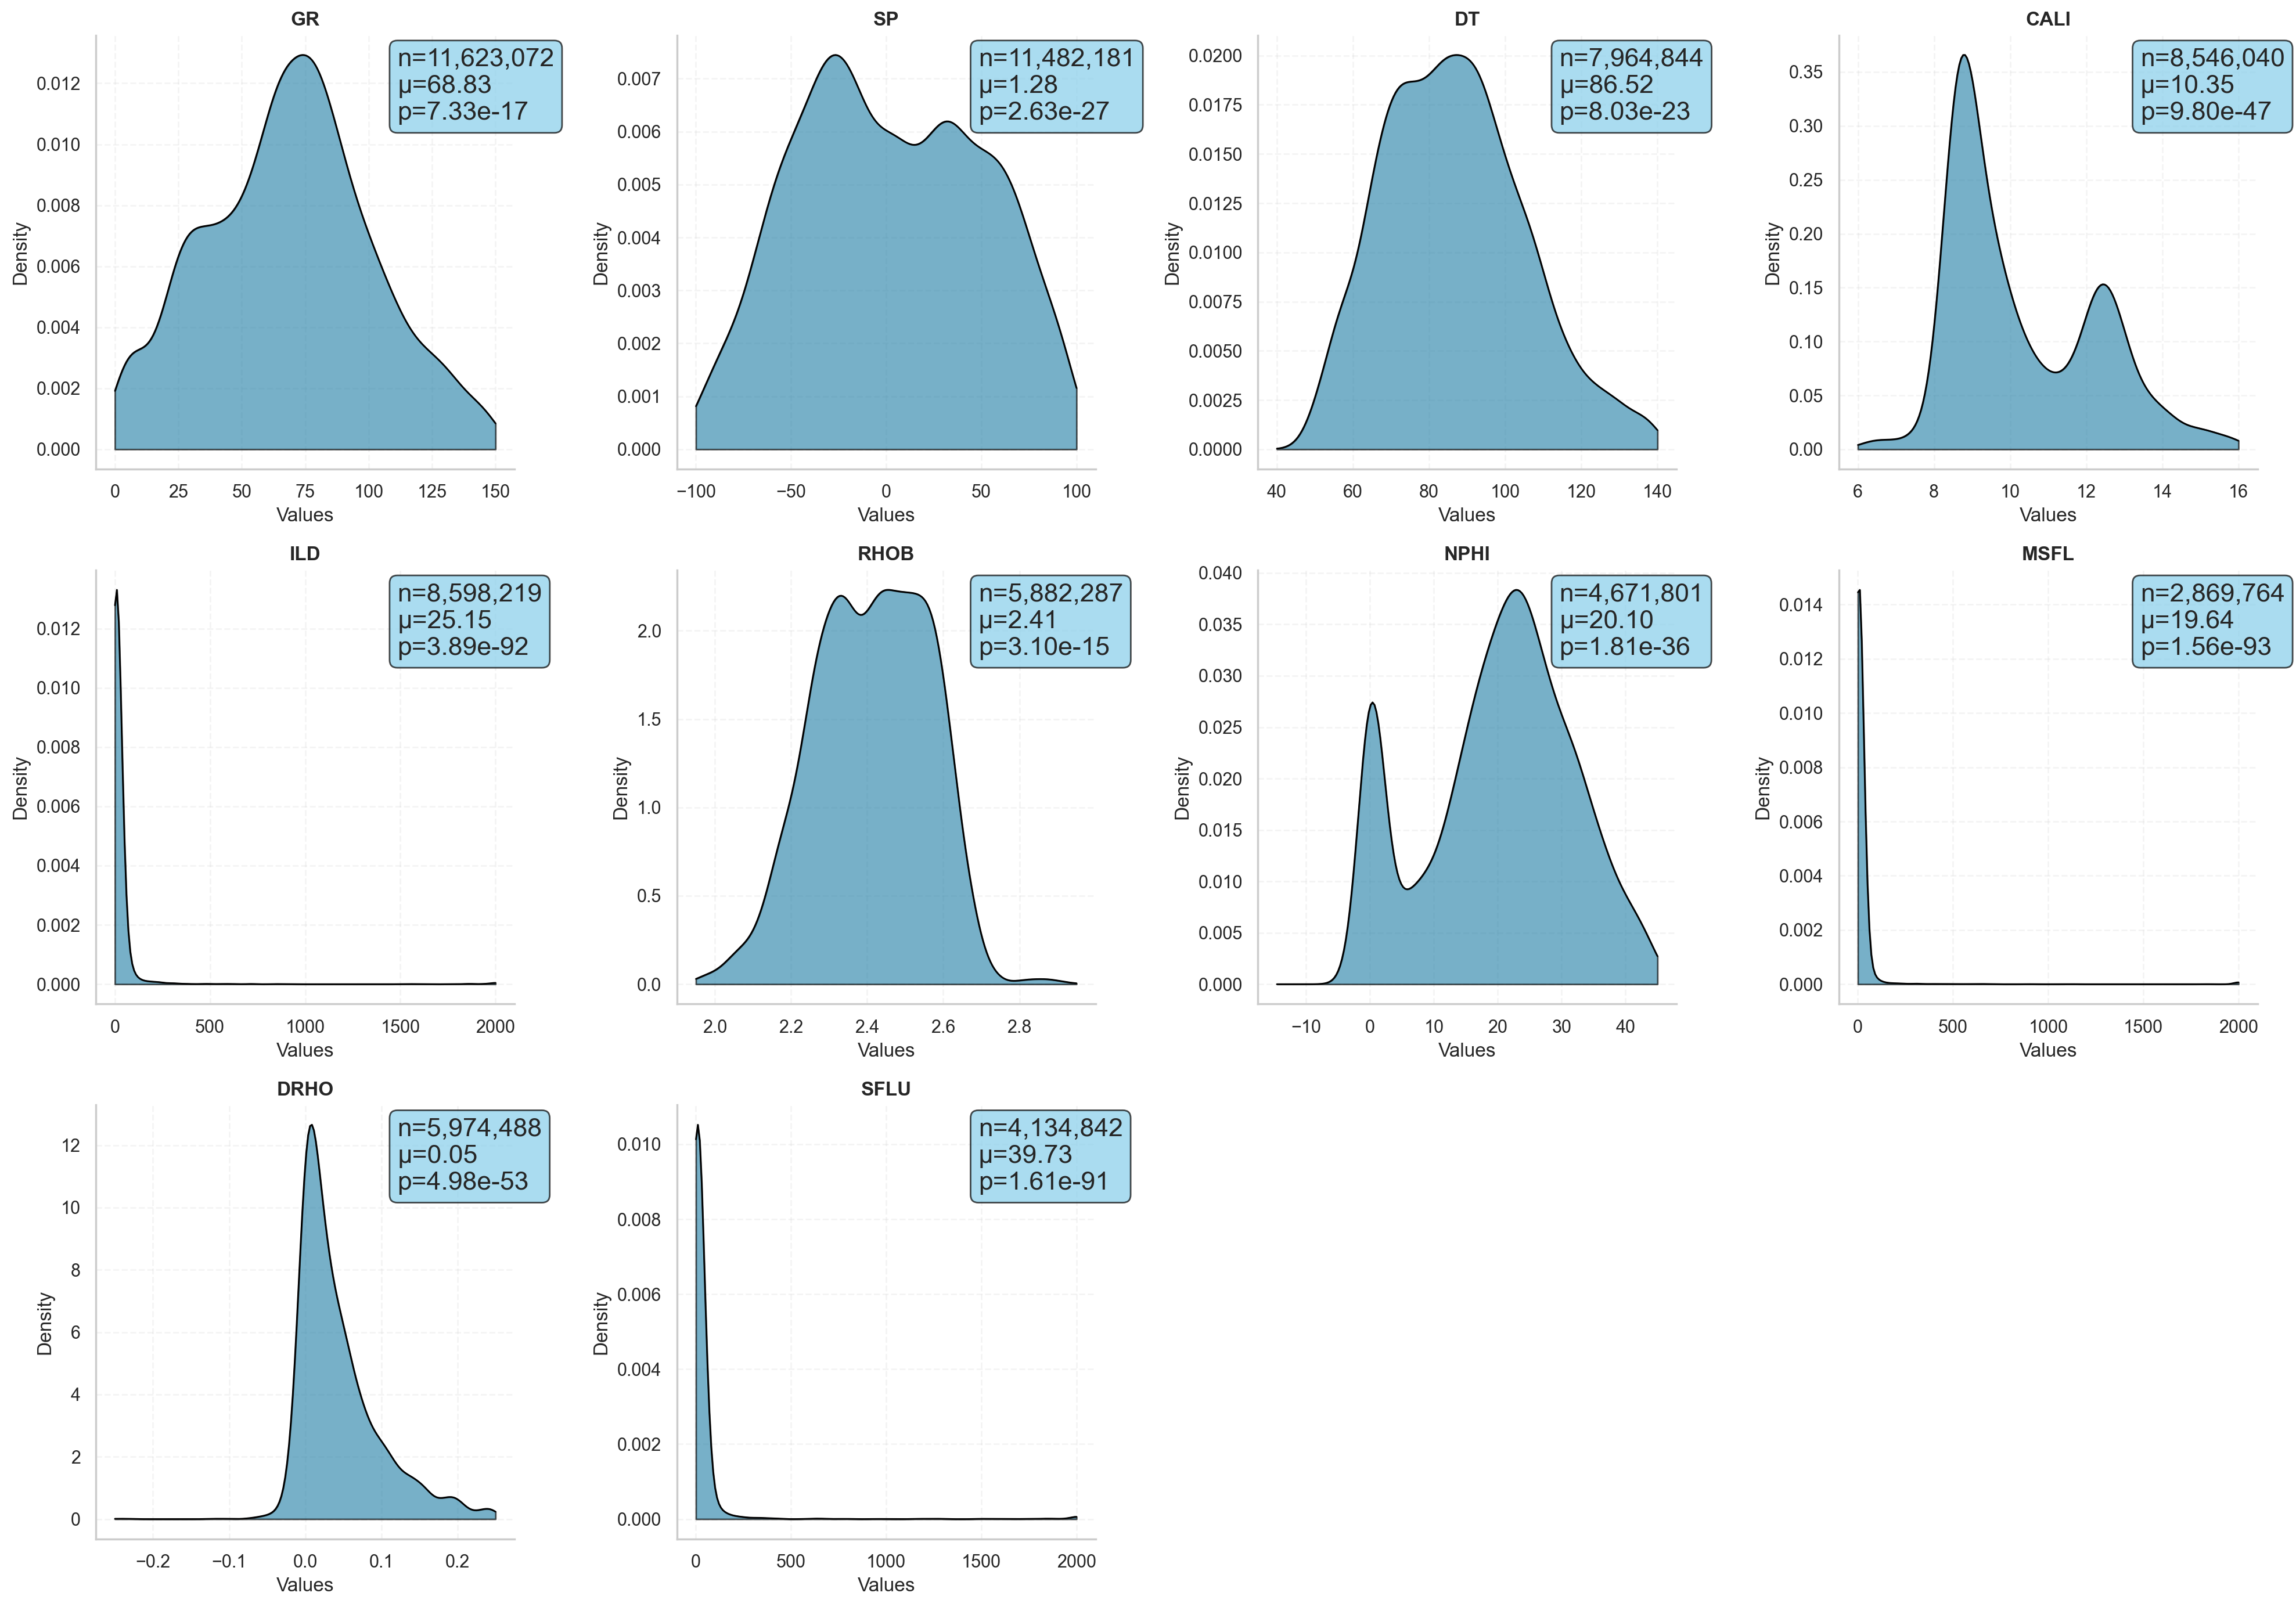

In [ ]:

############################ BELL CURVES - AREA PLOTS ########################

# Set up the plotting style
#plt.style.use('default')
#sns.set_palette("husl")

# Select only resistivity measurements
resistivity_columns = ['ILD', 'SFLU', 'MSFL']

# Calculate number of columns and create subplots
n_cols = 3
n_rows_dist = 1
fig, axes = plt.subplots(n_rows_dist, n_cols, figsize=(18, 5), dpi=200)
#fig.suptitle('Distribution Analysis (Area Plots) for Numeric Features', fontsize=16, fontweight='bold', y=0.995)

# Flatten axes for easier iteration
axes = axes.flatten()

# Create distribution plots with area fill
for i, col in enumerate(resistivity_columns):
    ax = axes[i]
    
    # Get data for the column (remove NaN values)
    data = df_features_filtered[col].dropna()
    
    if len(data) > 0:
        # Sample data for KDE computation
        data_sample = data.sample(min(5000, len(data)))
        
        # Create smooth area plot using KDE
        x = np.linspace(data.min(), data.max(), 200)
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(data_sample)
        y = kde(x)
        
        # Plot as filled area HORIZONTALLY
        ax.fill_between(x, y, alpha=0.65, color='#2E86AB', edgecolor='black', linewidth=1)
        ax.plot(x, y, color='black', linewidth=1)
        
        # Perform Shapiro-Wilk test
        sample_size = min(5000, len(data))
        data_sample_test = data.sample(sample_size) if len(data) > sample_size else data
        shapiro_stat, shapiro_p = stats.shapiro(data_sample_test)
        
        # Set title with statistics and Shapiro p-value
        ax.set_title(f'{col}', fontweight='bold')
        
        # Clean up axes
        ax.set_xlabel('Values')
        ax.set_ylabel('Density')
        ax.grid(True, alpha=0.2, linestyle='--')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Add normality indicator badge
        if shapiro_p > 0.05:
            badge_text = "✓ Normal"
            badge_color = '#A8D5BA'
        else:
            badge_text = "✗ Non-Normal"
            badge_color = '#FFB3BA'
        
        #ax.text(0.98, 0.95, badge_text, 
        #        transform=ax.transAxes, verticalalignment='top', horizontalalignment='right',
        #        bbox=dict(boxstyle='round,pad=0.4', facecolor=badge_color, 
        #                 alpha=0.7, edgecolor='gray', linewidth=1), fontsize=9, fontweight='bold')
        
        # Add a subtle statistics annotation
        ax.text(0.72, 0.97, f'n={len(data):,}\nμ={data.mean():.2f}\np={shapiro_p:.2e}', 
                transform=ax.transAxes, verticalalignment='top', fontsize=16,
                bbox=dict(edgecolor='black', boxstyle='round', alpha=0.7, facecolor='skyblue'))
    else:
        ax.text(0.5, 0.5, f'No data available for {col}', 
                transform=ax.transAxes, ha='center', va='center')
        ax.set_title(f'{col} - No Data', fontsize=11)

# Hide unused subplots
for i in range(len(resistivity_columns), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()


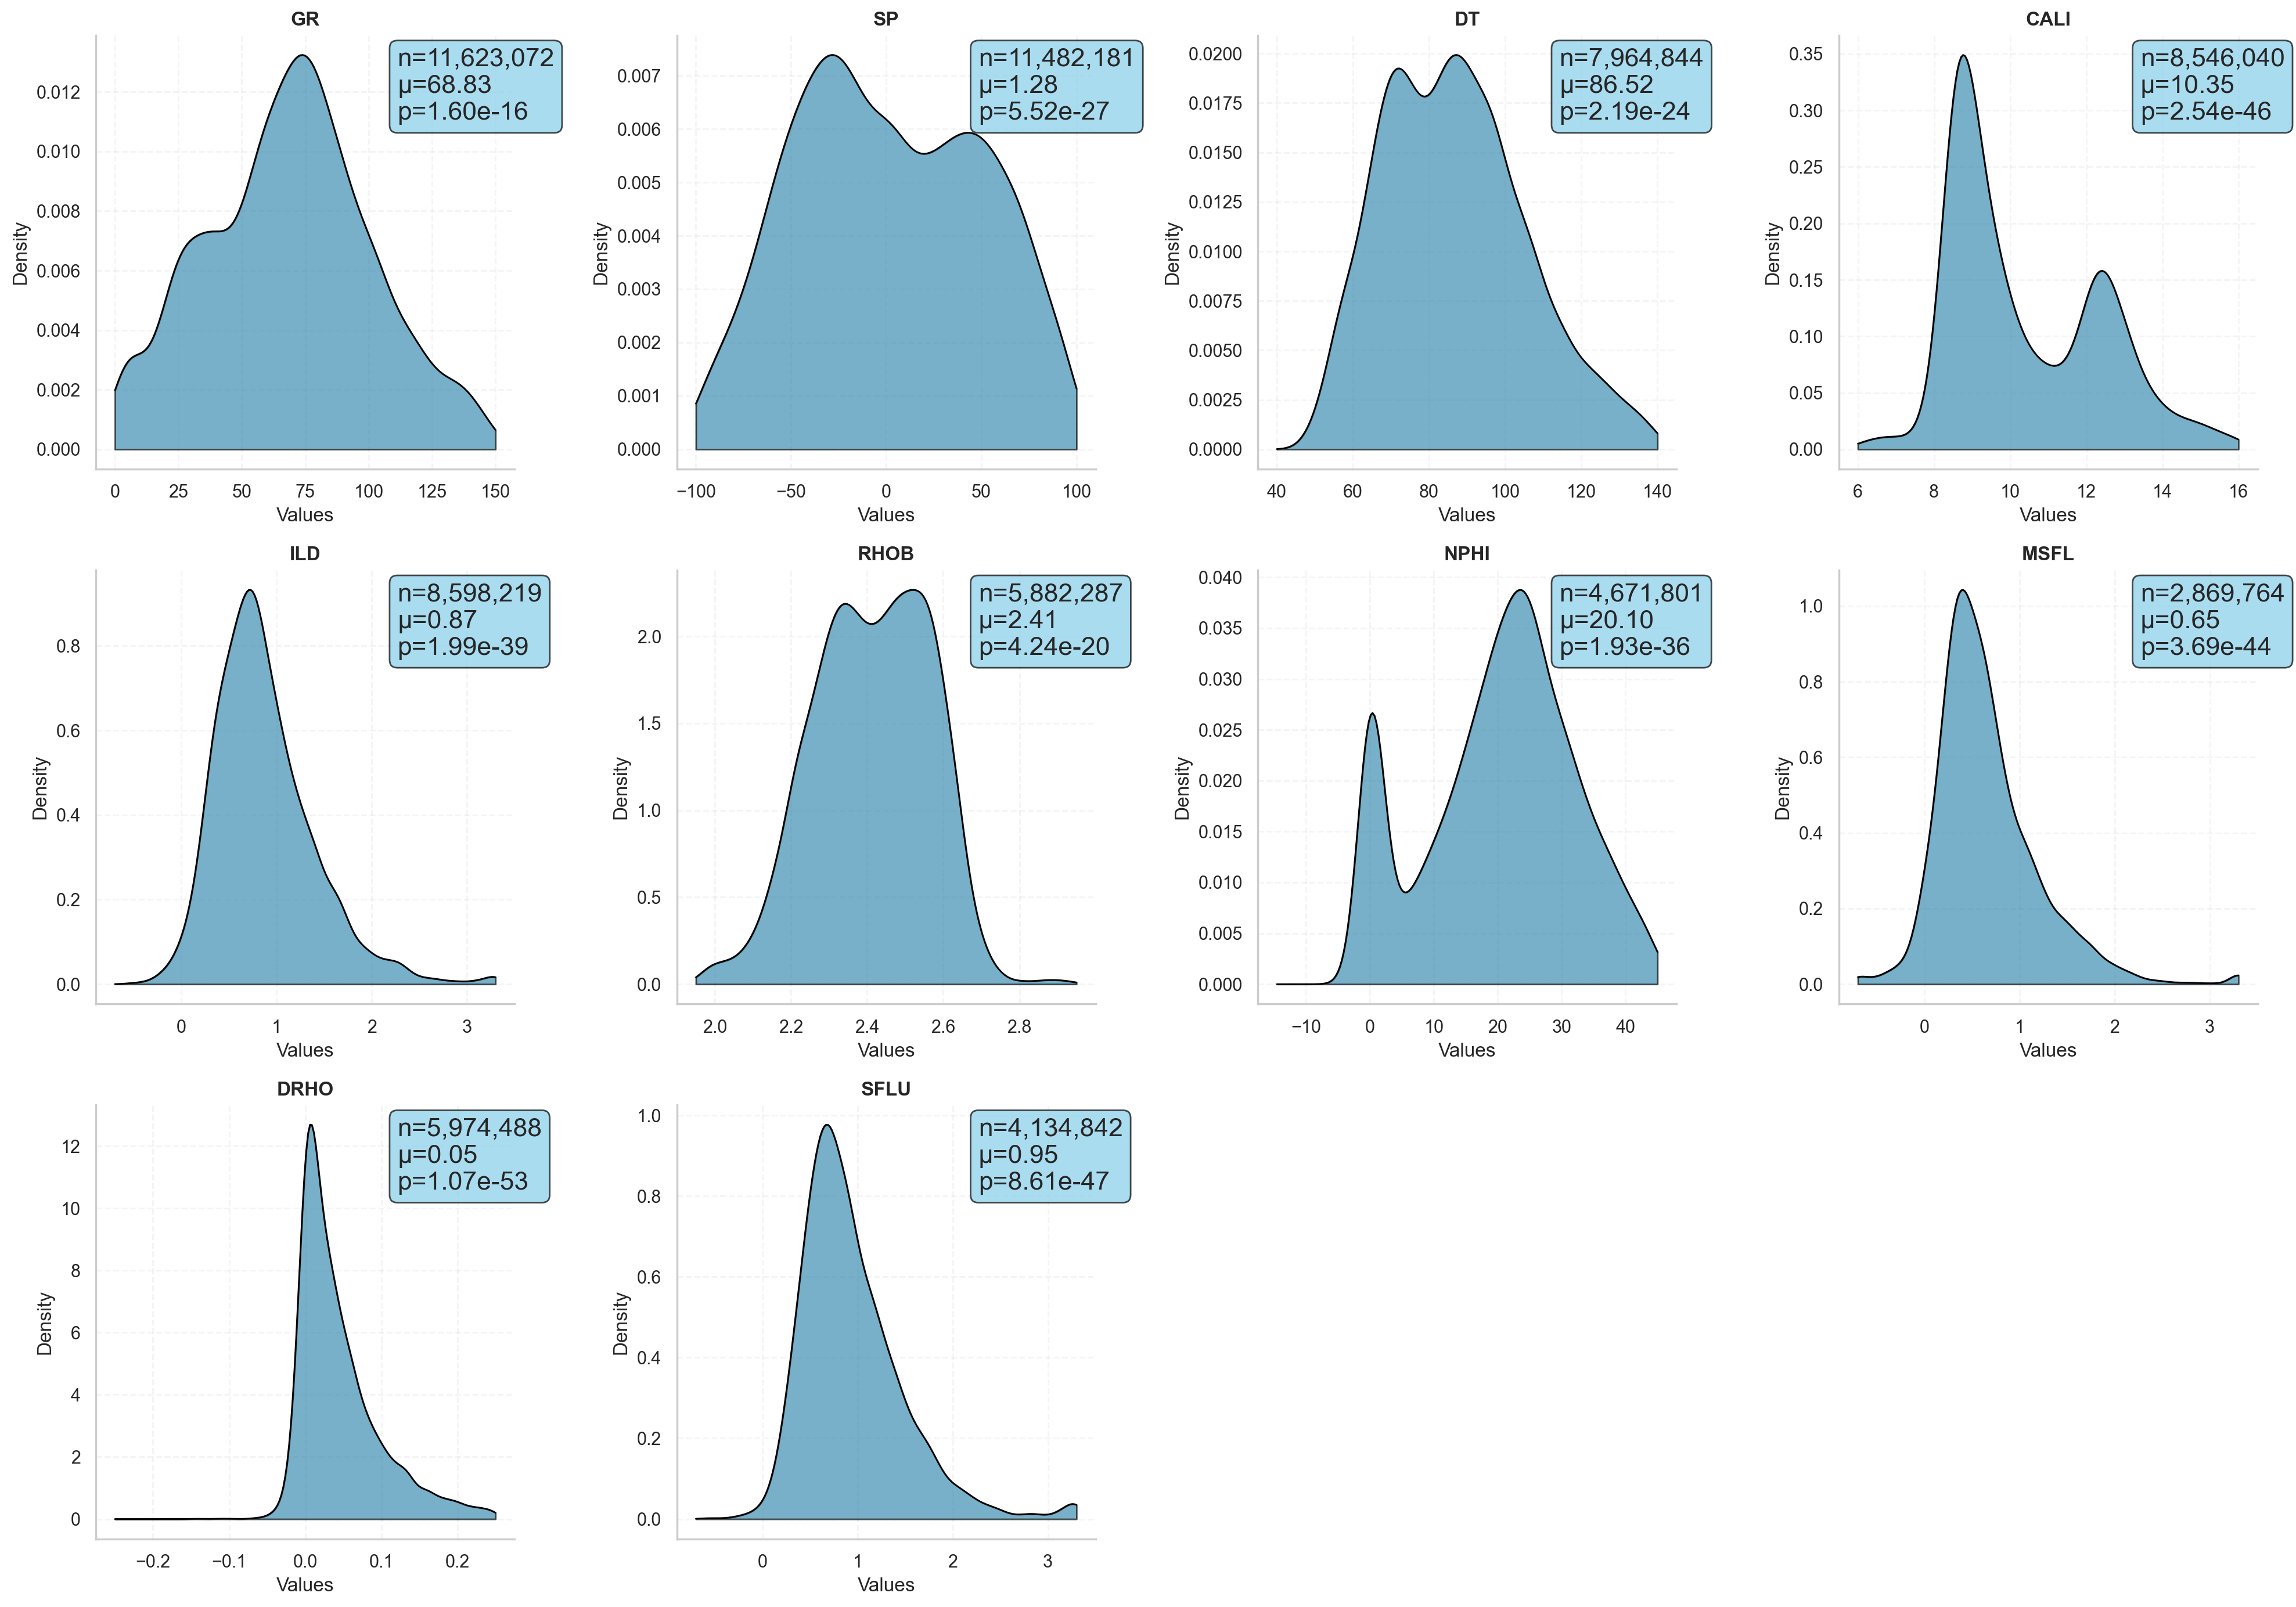

In [240]:
############################ BELL CURVES - AREA PLOTS ########################

# Set up the plotting style
#plt.style.use('default')
#sns.set_palette("husl")

# Calculate number of filtered numeric columns and create subplots
n_cols_dist = len(filtered_numeric_columns_clean)
n_cols = 4  # 2 columns for vertical layout
n_rows_dist = (n_cols_dist + n_cols - 2) // n_cols  # Calculate rows needed
fig, axes = plt.subplots(n_rows_dist, n_cols, figsize=(20, 14), dpi=200)
#fig.suptitle('Distribution Analysis (Area Plots) for Numeric Features', fontsize=16, fontweight='bold', y=0.995)

# Flatten axes for easier iteration
axes = axes.flatten()

# Create distribution plots with area fill
for i, col in enumerate(filtered_numeric_columns_clean):
    ax = axes[i]
    
    # Get data for the column (remove NaN values)
    data = df_features_filtered[col].dropna()
    
    if len(data) > 0:
        # Sample data for KDE computation
        data_sample = data.sample(min(5000, len(data)))
        
        # Create smooth area plot using KDE
        x = np.linspace(data.min(), data.max(), 200)
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(data_sample)
        y = kde(x)
        
        # Plot as filled area HORIZONTALLY
        ax.fill_between(x, y, alpha=0.65, color='#2E86AB', edgecolor='black', linewidth=1)
        ax.plot(x, y, color='black', linewidth=1)
        
        # Perform Shapiro-Wilk test
        sample_size = min(5000, len(data))
        data_sample_test = data.sample(sample_size) if len(data) > sample_size else data
        shapiro_stat, shapiro_p = stats.shapiro(data_sample_test)
        
        # Set title with statistics and Shapiro p-value
        ax.set_title(f'{col}', fontweight='bold')
        
        # Clean up axes
        ax.set_xlabel('Values')
        ax.set_ylabel('Density')
        ax.grid(True, alpha=0.2, linestyle='--')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Add normality indicator badge
        if shapiro_p > 0.05:
            badge_text = "✓ Normal"
            badge_color = '#A8D5BA'
        else:
            badge_text = "✗ Non-Normal"
            badge_color = '#FFB3BA'
        
        #ax.text(0.98, 0.95, badge_text, 
        #        transform=ax.transAxes, verticalalignment='top', horizontalalignment='right',
        #        bbox=dict(boxstyle='round,pad=0.4', facecolor=badge_color, 
        #                 alpha=0.7, edgecolor='gray', linewidth=1), fontsize=9, fontweight='bold')
        
        # Add a subtle statistics annotation
        ax.text(0.72, 0.97, f'n={len(data):,}\nμ={data.mean():.2f}\np={shapiro_p:.2e}', 
                transform=ax.transAxes, verticalalignment='top', fontsize=16,
                bbox=dict(edgecolor='black', boxstyle='round', alpha=0.7, facecolor='skyblue'))
    else:
        ax.text(0.5, 0.5, f'No data available for {col}', 
                transform=ax.transAxes, ha='center', va='center')
        ax.set_title(f'{col} - No Data', fontsize=11)

# Hide unused subplots
for i in range(len(filtered_numeric_columns_clean), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

In [13]:
#######################################  Correlation Summary  #######################################
# Print strong correlations (absolute value > 0.7)
print("=" * 50)
strong_corr = []
normal_corr = []
weak_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.7:
            strong_corr.append({
                'Feature 1': correlation_matrix.columns[i],
                'Feature 2': correlation_matrix.columns[j],
                'Correlation': corr_value
            })
        elif abs(corr_value) > 0.4:
            normal_corr.append({
                'Feature 1': correlation_matrix.columns[i],
                'Feature 2': correlation_matrix.columns[j],
                'Correlation': corr_value
            })
        elif abs(corr_value) > 0.1:
            weak_corr.append({
                'Feature 1': correlation_matrix.columns[i],
                'Feature 2': correlation_matrix.columns[j],
                'Correlation': corr_value
            })

if strong_corr:
    strong_corr_df = pd.DataFrame(strong_corr).sort_values('Correlation', key=abs, ascending=False)
    print(strong_corr_df)
else:
    print("No strong correlations found (|r| > 0.7)")
    
if normal_corr:
    normal_corr_df = pd.DataFrame(normal_corr).sort_values('Correlation', key=abs, ascending=False)
    print("\nNormal Correlations (|r| > 0.4):")
    print(normal_corr_df)
else:
    print("No normal correlations found (|r| > 0.4)")
if weak_corr:
    weak_corr_df = pd.DataFrame(weak_corr).sort_values('Correlation', key=abs, ascending=False)
    print("\nWeak Correlations (|r| > 0.1):")
    print(weak_corr_df)
else:
    print("No weak correlations found (|r| > 0.1)")





#######################################  Normality Test Summary  #######################################



# Print summary of normality tests
print("\nNormality Test Summary:")
print("=" * 50)
print("Shapiro-Wilk Test Results (p > 0.05 suggests normal distribution):\n")

normality_results = []
for col in filtered_numeric_columns_clean:
    data = df_features_filtered[col].dropna()
    if len(data) > 3:  # Minimum required for Shapiro-Wilk
        sample_size = min(5000, len(data))
        data_sample = data.sample(sample_size) if len(data) > sample_size else data
        shapiro_stat, shapiro_p = stats.shapiro(data_sample)
        
        normality_results.append({
            'Feature': col,
            'Sample_Size': len(data_sample),
            'Shapiro_Statistic': shapiro_stat,
            'P_Value': shapiro_p,
            'Is_Normal': 'Yes' if shapiro_p > 0.05 else 'No'
        })

normality_df = pd.DataFrame(normality_results)
print(normality_df.round(6))

  Feature 1 Feature 2  Correlation
0     depth       top     0.996653

Normal Correlations (|r| > 0.4):
  Feature 1 Feature 2  Correlation
0        DT      RHOB    -0.616616
1        DT      NPHI     0.508030
5      MSFL      SFLU     0.478711
4      RHOB       top     0.458236
2        DT       top    -0.444471
3       ILD      SFLU     0.430823

Weak Correlations (|r| > 0.1):
   Feature 1 Feature 2  Correlation
8         GR      NPHI     0.384336
0      depth        DT    -0.371229
20      RHOB      NPHI    -0.364154
4      depth      rock    -0.357265
5         GR        DT     0.277395
18       ILD      MSFL     0.275742
2      depth      RHOB     0.274011
25      NPHI      DRHO     0.256551
12        DT       ILD    -0.229389
22      RHOB      SFLU     0.227252
15        DT      rock     0.202815
16      CALI      DRHO     0.200857
10        GR      rock     0.190075
14        DT      SFLU    -0.189492
17       ILD      RHOB     0.175703
27      DRHO       top     0.173033
13     

In [ ]:
import pandas as pd
import sqlite3
import numpy as np
import seaborn as sns
from scipy import stats

conn = sqlite3.connect('../slide/database/features.db')
query = "SELECT * FROM Features"
df_features = pd.read_sql_query(query, conn)
df_features.info()


In [ ]:
import plotly.graph_objs as go
import plotly.offline as pyo

# Calculate cumulative percentage for Pareto chart
df['cumsum'] = df['total_wells'].cumsum()
df['cumperc'] = (df['cumsum'] / df['total_wells'].sum()) * 100

# Create bar trace for total_wells
bar_trace = go.Bar(
    x=df['channel'],
    y=df['total_wells'],
    name='Total Wells',
    marker=dict(color='rgba(31, 119, 180, 0.7)')
)

# Create line trace for cumulative percentage
line_trace = go.Scatter(
    x=df['channel'],
    y=df['cumperc'],
    name='Cumulative Percentage',
    yaxis='y2',
    mode='lines+markers',
    line=dict(color='orange', width=2)
)

layout = go.Layout(
    title='Interactive Pareto Chart of Channels by Total Wells',
    xaxis=dict(title='Channel', tickangle=45),
    yaxis=dict(title='Total Wells', showgrid=False),
    yaxis2=dict(
        title='Cumulative Percentage (%)',
        overlaying='y',
        side='right',
        range=[0, 110],
        showgrid=False
    ),
    legend=dict(x=0.75, y=1.15, orientation='h'),
    margin=dict(b=120),
    width=1000,
    height=600
)

fig_plotly = go.Figure(data=[bar_trace, line_trace], layout=layout)
pyo.iplot(fig_plotly)